In [1]:
import time
notebook_start = time.perf_counter()

import  os, json, joblib, pandas as pd, numpy as np, matplotlib.pyplot as plt
import  thermoift.PLOT_SETTINGS as ps
from    matplotlib.ticker import AutoMinorLocator
from    thermoift import MLPostprocessing, plot_correlation_heatmap, print_model_metrics
from    thermoift.rng_utils import get_rng
from    sklearn.model_selection import train_test_split, cross_val_score
from    sklearn.ensemble import RandomForestRegressor
from    sklearn.metrics import mean_squared_error
from    sklearn.model_selection import learning_curve

OUTPUT_FOLDER = "RF_Pbubble_OUTPUTS"
TEST_ROWS     = None
N_JOBS        = int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count() or 1))
print(f"RF parallel jobs: {N_JOBS}")


RF parallel jobs: 24


In [2]:
df = pd.read_csv("../interfacial_results_dataset_A4.csv")

if isinstance(TEST_ROWS, str) and TEST_ROWS.strip().lower() in ("", "none", "null"):
    TEST_ROWS = None
if TEST_ROWS is not None:
    TEST_ROWS = int(TEST_ROWS)
    df = df.iloc[:TEST_ROWS].copy()
    print(f"Test mode: using first {TEST_ROWS} rows only")

print(f"Total samples: {len(df)}")
print(f"\nP_bubble statistics:")
print(df["P_bubble"].describe())

Total samples: 19361

P_bubble statistics:
count    19361.000000
mean        41.311216
std         21.196807
min          3.338831
25%         24.499412
50%         38.379096
75%         56.527415
max        162.875312
Name: P_bubble, dtype: float64


In [3]:
target     = "P_bubble"
SEED       = 50015
rng        = get_rng(seed=SEED)

z_columns  = [col for col in df.columns if col.startswith("z_")]
Z_non_zero = [col for col in z_columns if (df[col] != 0).any()]
features   = ["temperature", "pressure"] + Z_non_zero

print(f"Selected features: {features}")

X = df[features]
y = df[target]

# 70/15/15 split: first 70/30, then split 30 into 15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"\nTraining samples:   {X_train.shape[0]}")
print(f"Testing samples:    {X_test.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Selected features: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']

Training samples:   13552
Testing samples:    2904
Validation samples: 2905


Feature correlations with P_bubble:
pressure              0.825622
z_hydrogen            0.679409
temperature           0.555460
z_hydrogen sulfide    0.012783
z_nitrogen            0.009007
z_argon              -0.004744
z_carbon monoxide    -0.025431
z_oxygen             -0.037786
z_methane            -0.095861
z_carbon dioxide     -0.269389
Name: P_bubble, dtype: float64


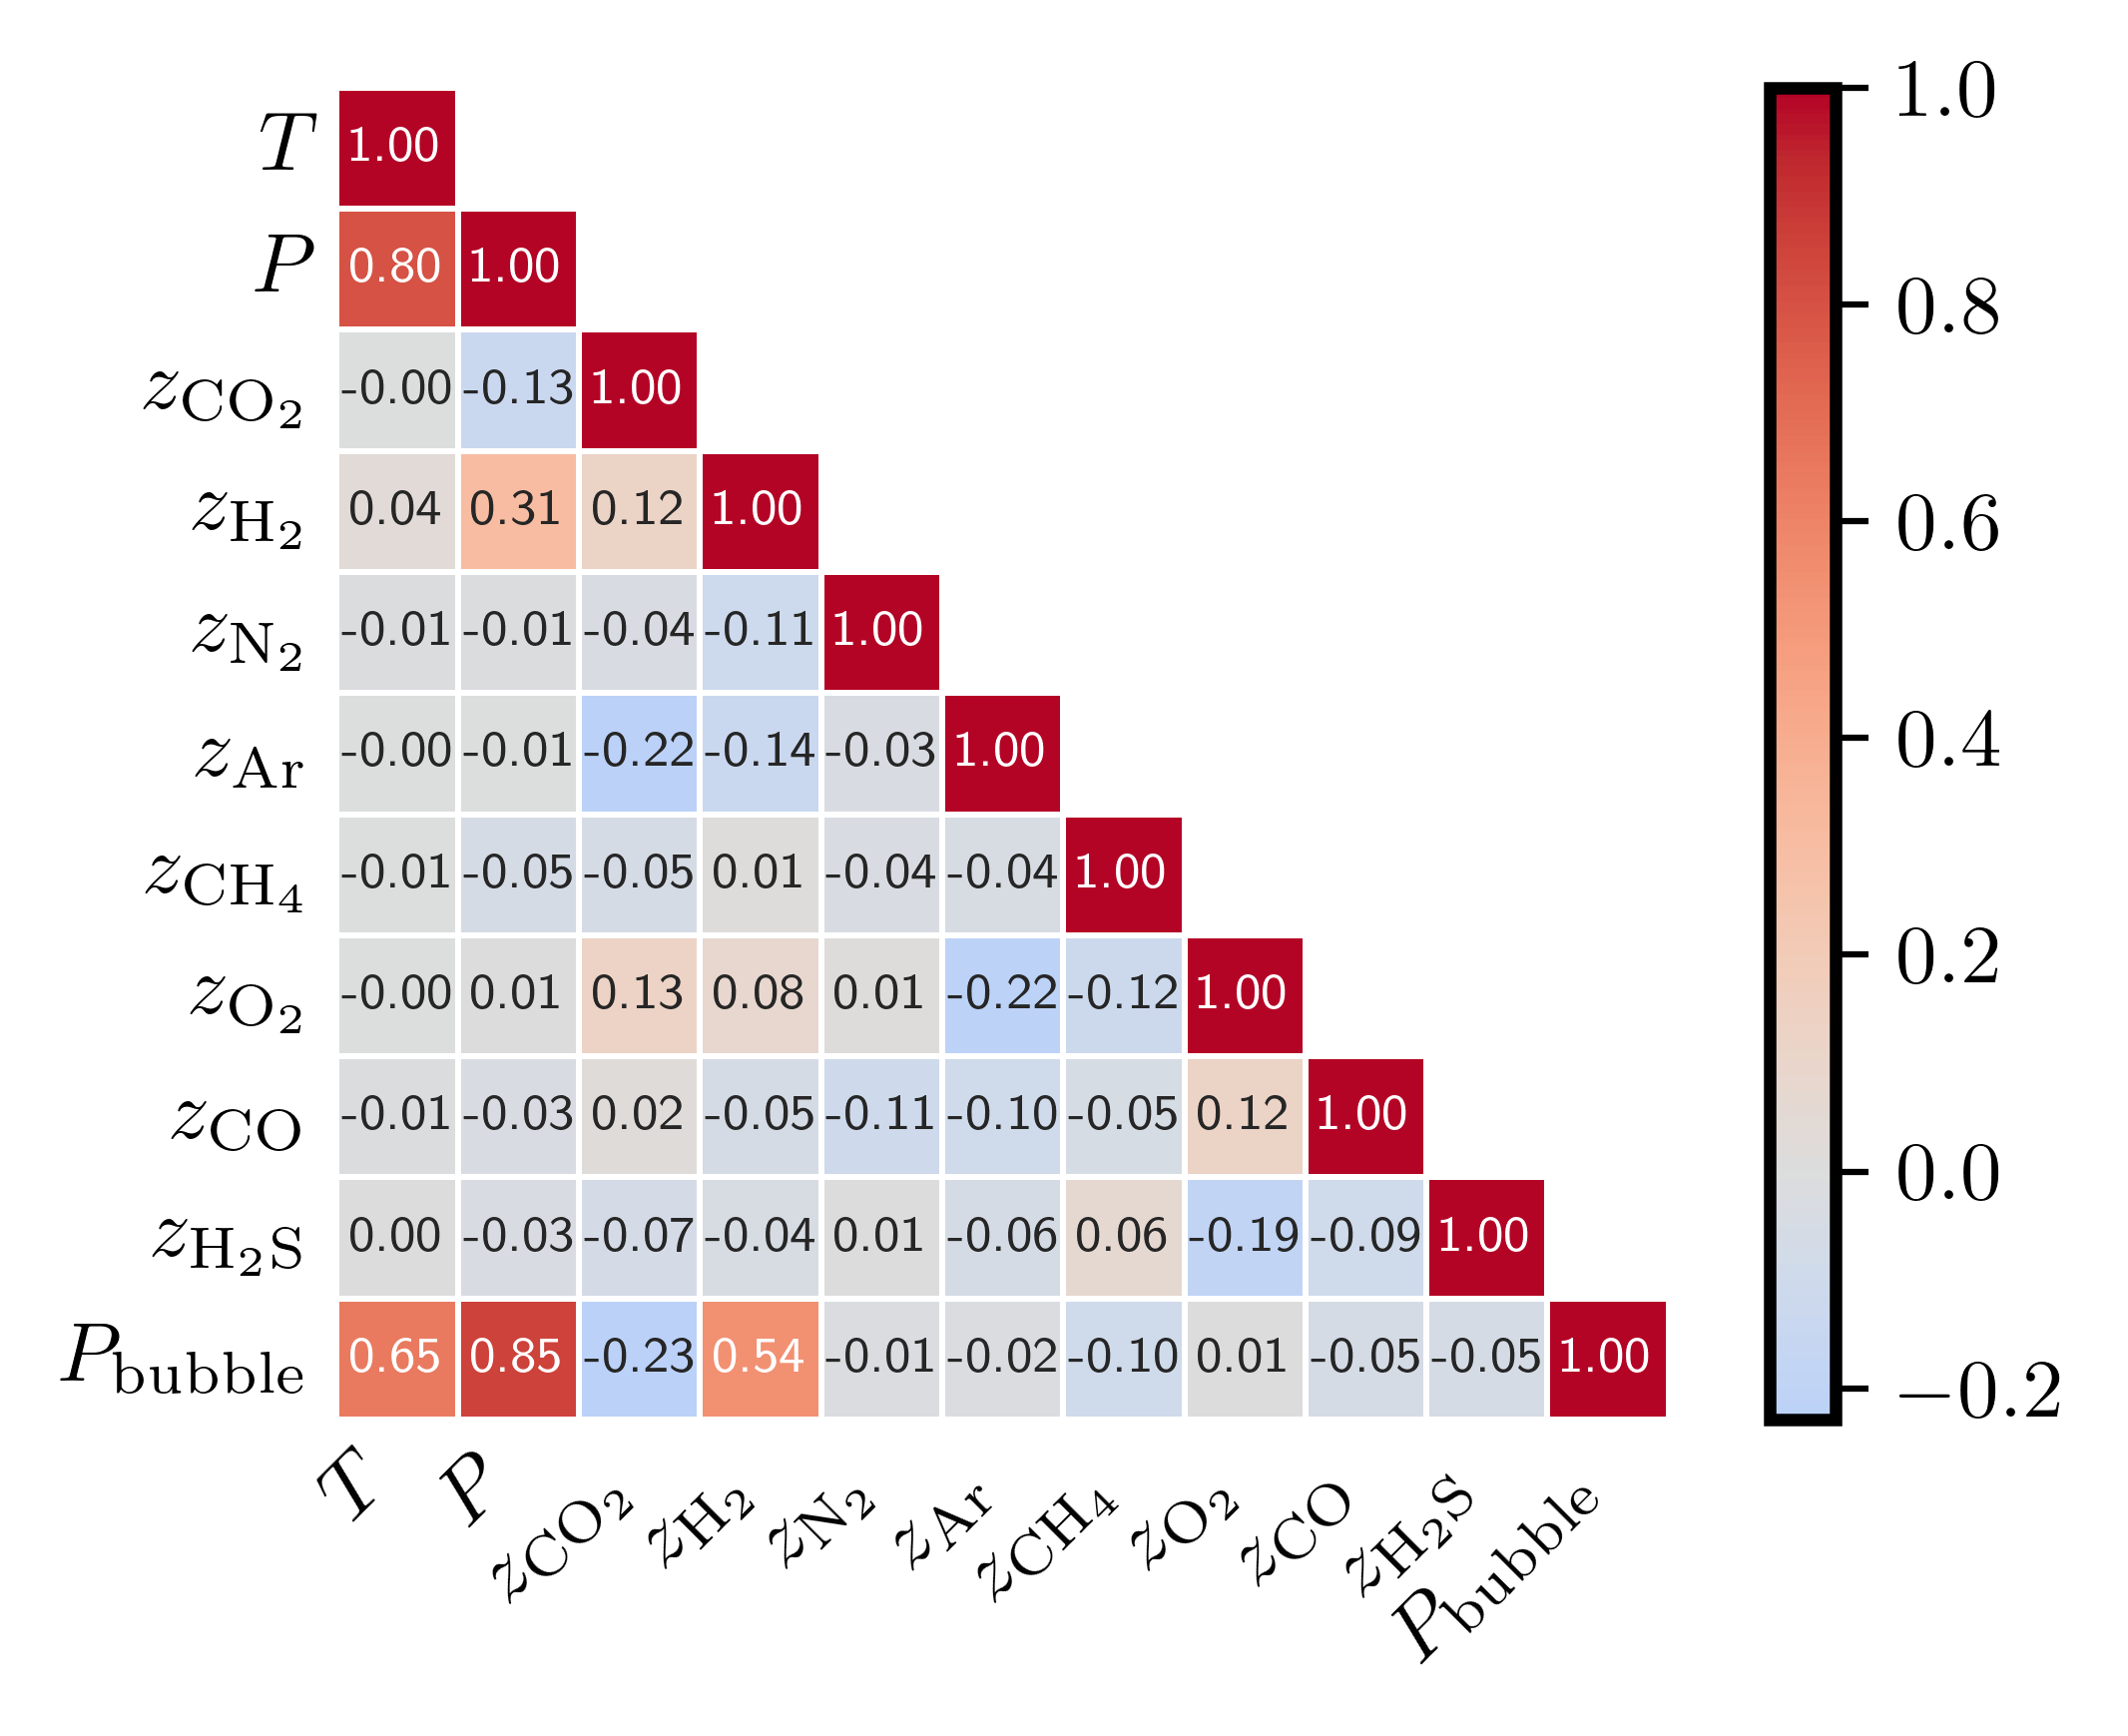

(<Figure size 2400x1800 with 2 Axes>, <Axes: >)

In [4]:
plot_correlation_heatmap(df, features, target, save_path="RF_P_bubble_correlation", folder=OUTPUT_FOLDER)

In [5]:
# Train Random Forest model

Trees = 200

rf_model = RandomForestRegressor(
    n_estimators=Trees,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=SEED,
    oob_score=True,
    n_jobs=N_JOBS
)

rf_model.fit(X_train, y_train)
print(f"OOB R² Score: {rf_model.oob_score_:.6f}")

# Predictions
y_train_pred    = rf_model.predict(X_train)
y_test_pred     = rf_model.predict(X_test)
y_val_pred      = rf_model.predict(X_val)

# Metrics
metrics = print_model_metrics(y_train, y_train_pred, y_test, y_test_pred, target, y_val=y_val, y_val_pred=y_val_pred)

OOB R² Score: 0.997150
Model Performance for P_bubble

Training Set:
  R²:   0.999621
  RMSE: 0.410094 bar
  MAE:  0.215893 bar

Test Set:
  R²:   0.997839
  RMSE: 1.017146 bar
  MAE:  0.554136 bar

Validation Set:
  R²:   0.997584
  RMSE: 1.040074 bar
  MAE:  0.560395 bar


In [6]:
results_df = pd.DataFrame({
    "idx": np.concatenate([y_train.index, y_test.index, y_val.index]),
    "actual": np.concatenate([y_train.values, y_test.values, y_val.values]),
    "predicted": np.concatenate([y_train_pred, y_test_pred, y_val_pred]),
    "split": ["train"]*len(y_train) + ["test"]*len(y_test) + ["val"]*len(y_val),
})
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
results_df.to_csv(os.path.join(OUTPUT_FOLDER, f"RF_{target}_predictions.csv"), index=False)
print(f"Predictions saved: {len(results_df)} rows")

# Save fitted model for future use without retraining
model_path = os.path.join(OUTPUT_FOLDER, f"RF_{target}_model.joblib")
joblib.dump(rf_model, model_path)
print(f"Model saved to: {model_path}")

Predictions saved: 19361 rows
Model saved to: RF_Pbubble_OUTPUTS/RF_P_bubble_model.joblib


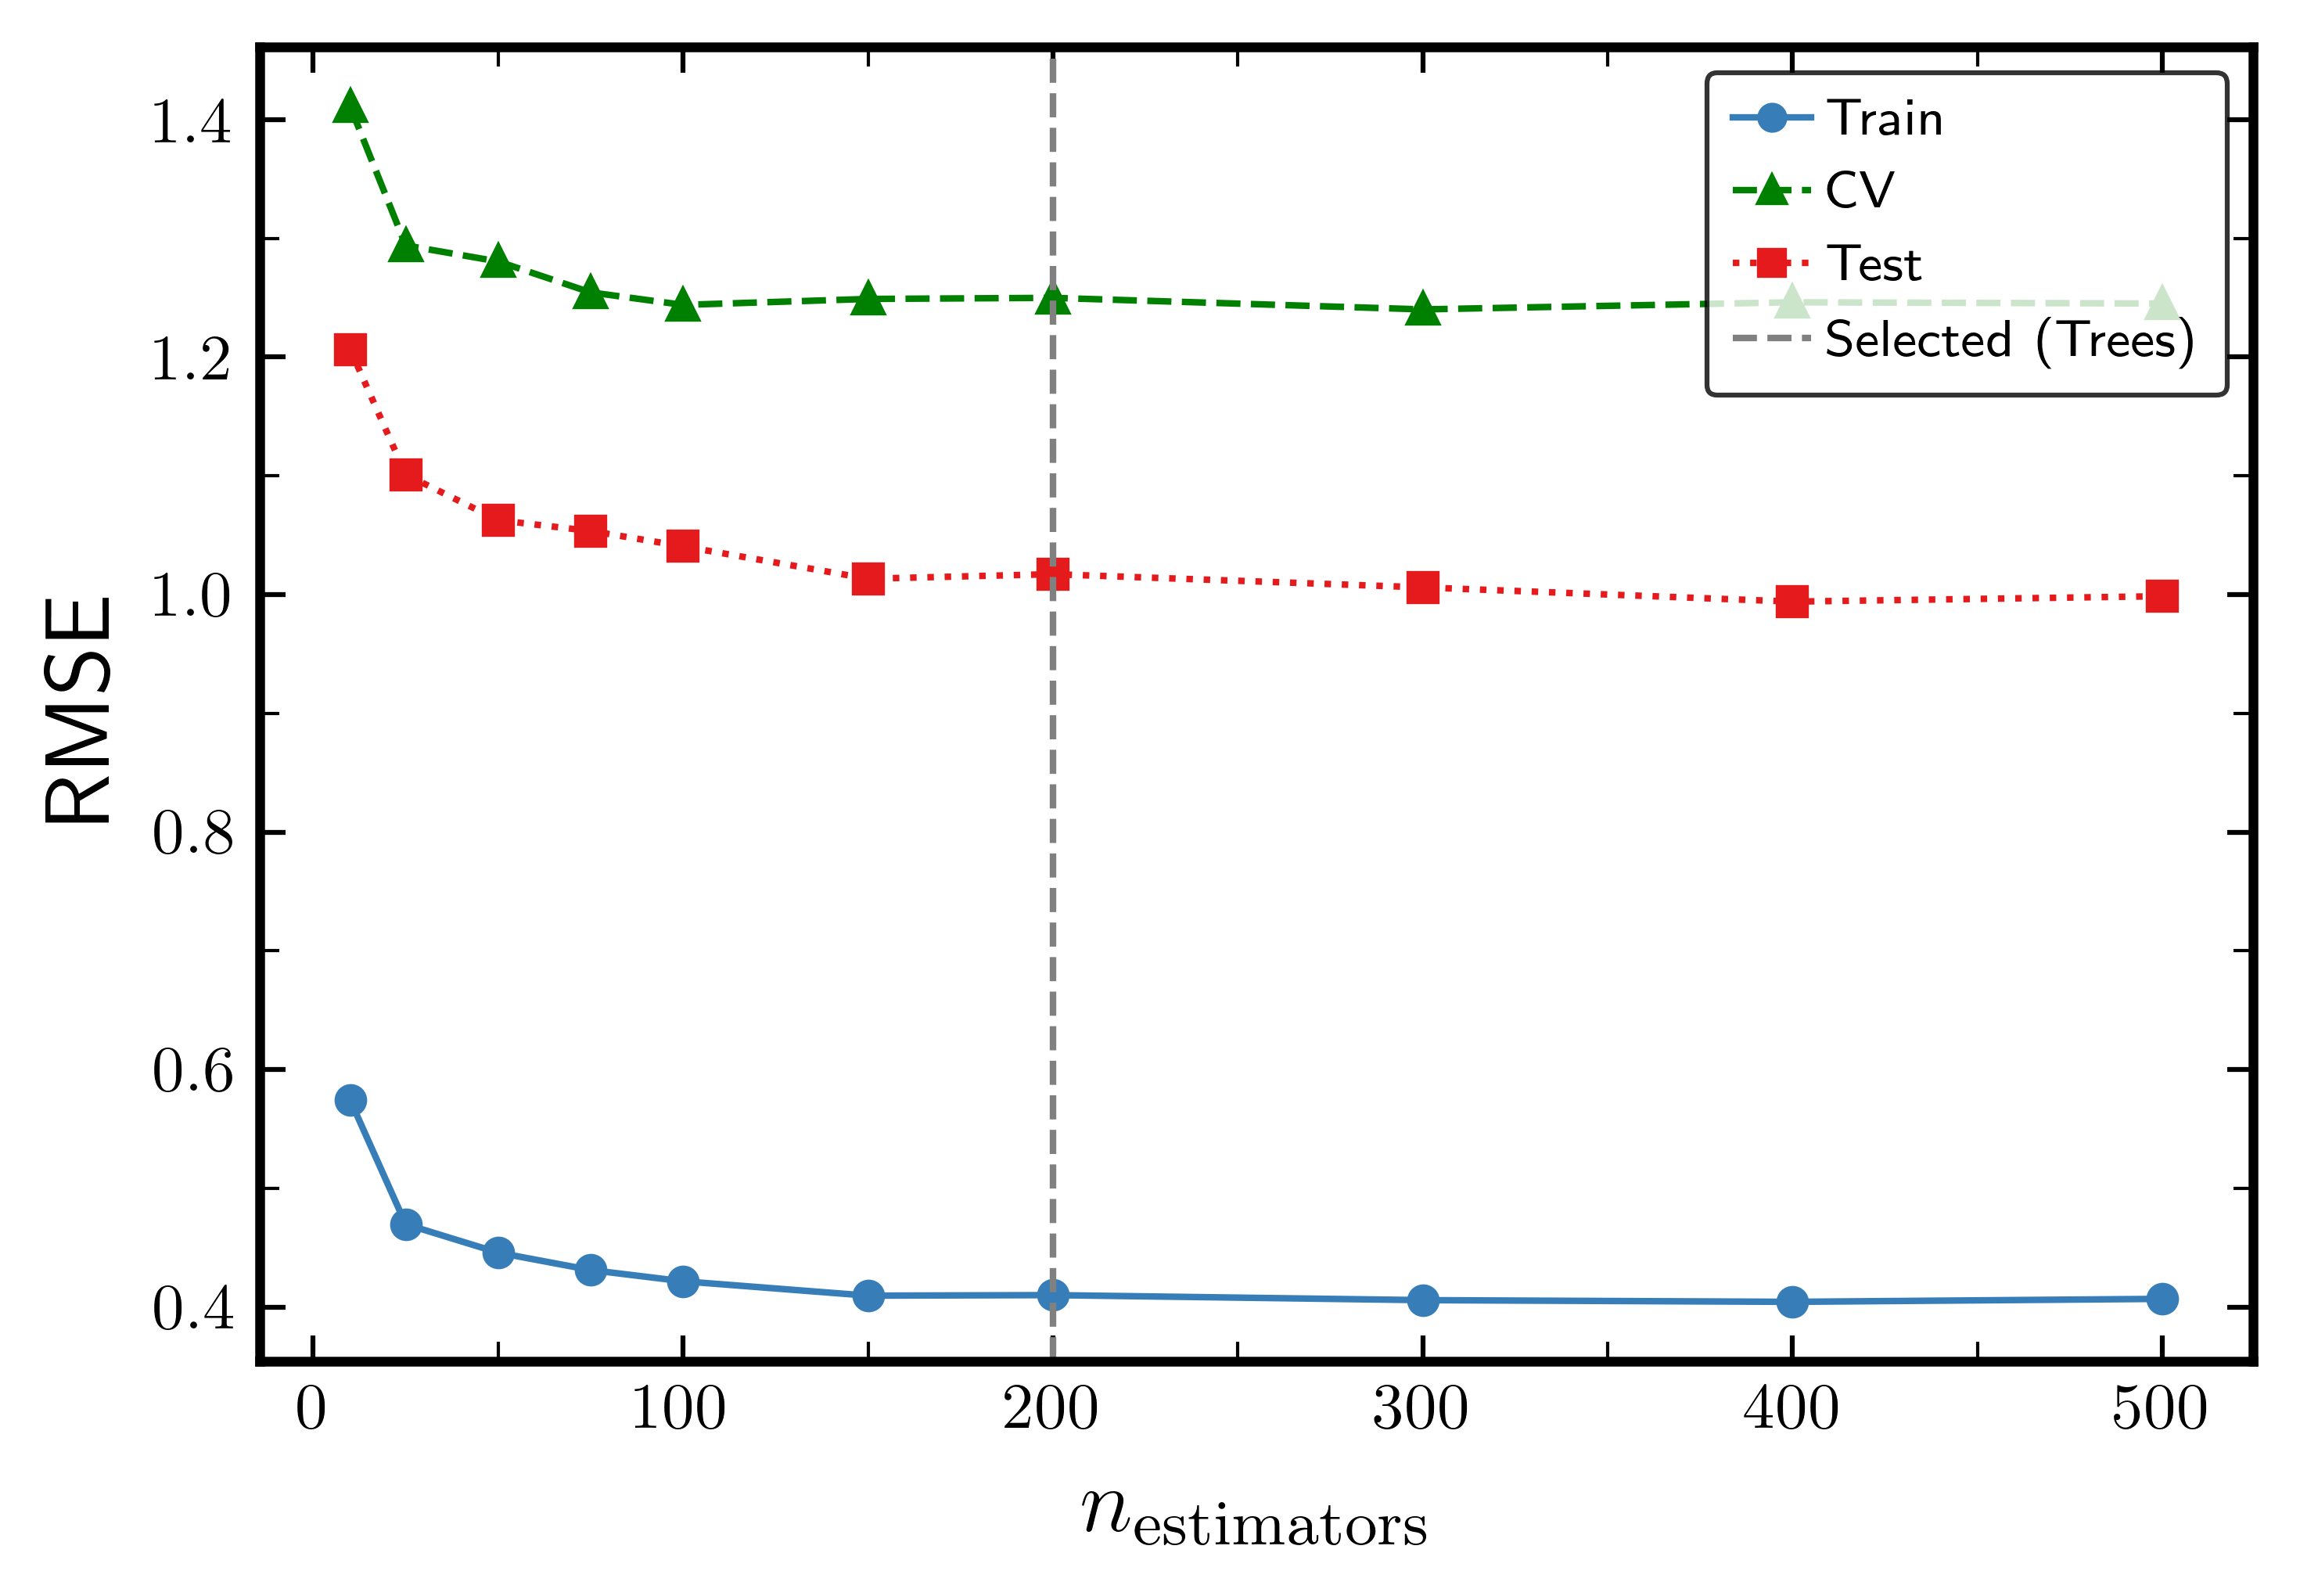

Saved: RF_P_bubble_nestimators_convergence


In [7]:
# n_estimators convergence: RMSE vs number of trees
# Hyperparameter comparison uses CV RMSE; test RMSE is shown only as a holdout reference.
checkpoints = [10, 25, 50, 75, 100, 150, 200, 300, 400, 500]
train_rmse_conv = []
cv_rmse_conv    = []
test_rmse_conv  = []

for n in checkpoints:
    _conv_model = RandomForestRegressor(
        n_estimators=n, max_depth=None, min_samples_split=2,
        min_samples_leaf=1, random_state=SEED, n_jobs=N_JOBS
    )
    _conv_model.fit(X_train, y_train)
    train_rmse_conv.append(np.sqrt(mean_squared_error(y_train, _conv_model.predict(X_train))))
    test_rmse_conv.append( np.sqrt(mean_squared_error(y_test,  _conv_model.predict(X_test))))
    cv_rmse_conv.append(
        -cross_val_score(
            _conv_model, X_train, y_train, cv=5,
            scoring='neg_root_mean_squared_error',
            n_jobs=N_JOBS,
        ).mean()
    )

fig, ax = ps.plot_init(w=5, h=3.5)
ax.plot(checkpoints, train_rmse_conv, marker='o', markersize=ps.markersize, lw=ps.linewidth,
        color=ps.colors[2], label='Train')
ax.plot(checkpoints, cv_rmse_conv, marker='^', markersize=ps.markersize, lw=ps.linewidth,
        color=ps.colors[1], label='CV')
ax.plot(checkpoints, test_rmse_conv,  marker='s', markersize=ps.markersize, lw=ps.linewidth,
        color=ps.colors[0], label='Test')
ax.axvline(Trees, ls='--', color='gray', lw=ps.linewidth, label='Selected (Trees)')
ax.set_xlabel(r"$n_{\mathrm{estimators}}$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"RMSE", fontsize=ps.label_fontsize)
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='minor', length=3)
ps.style_legend(ax, loc='upper right')
plt.tight_layout()
ps.save_plot(fig, f"RF_{target}_nestimators_convergence", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: RF_{target}_nestimators_convergence")


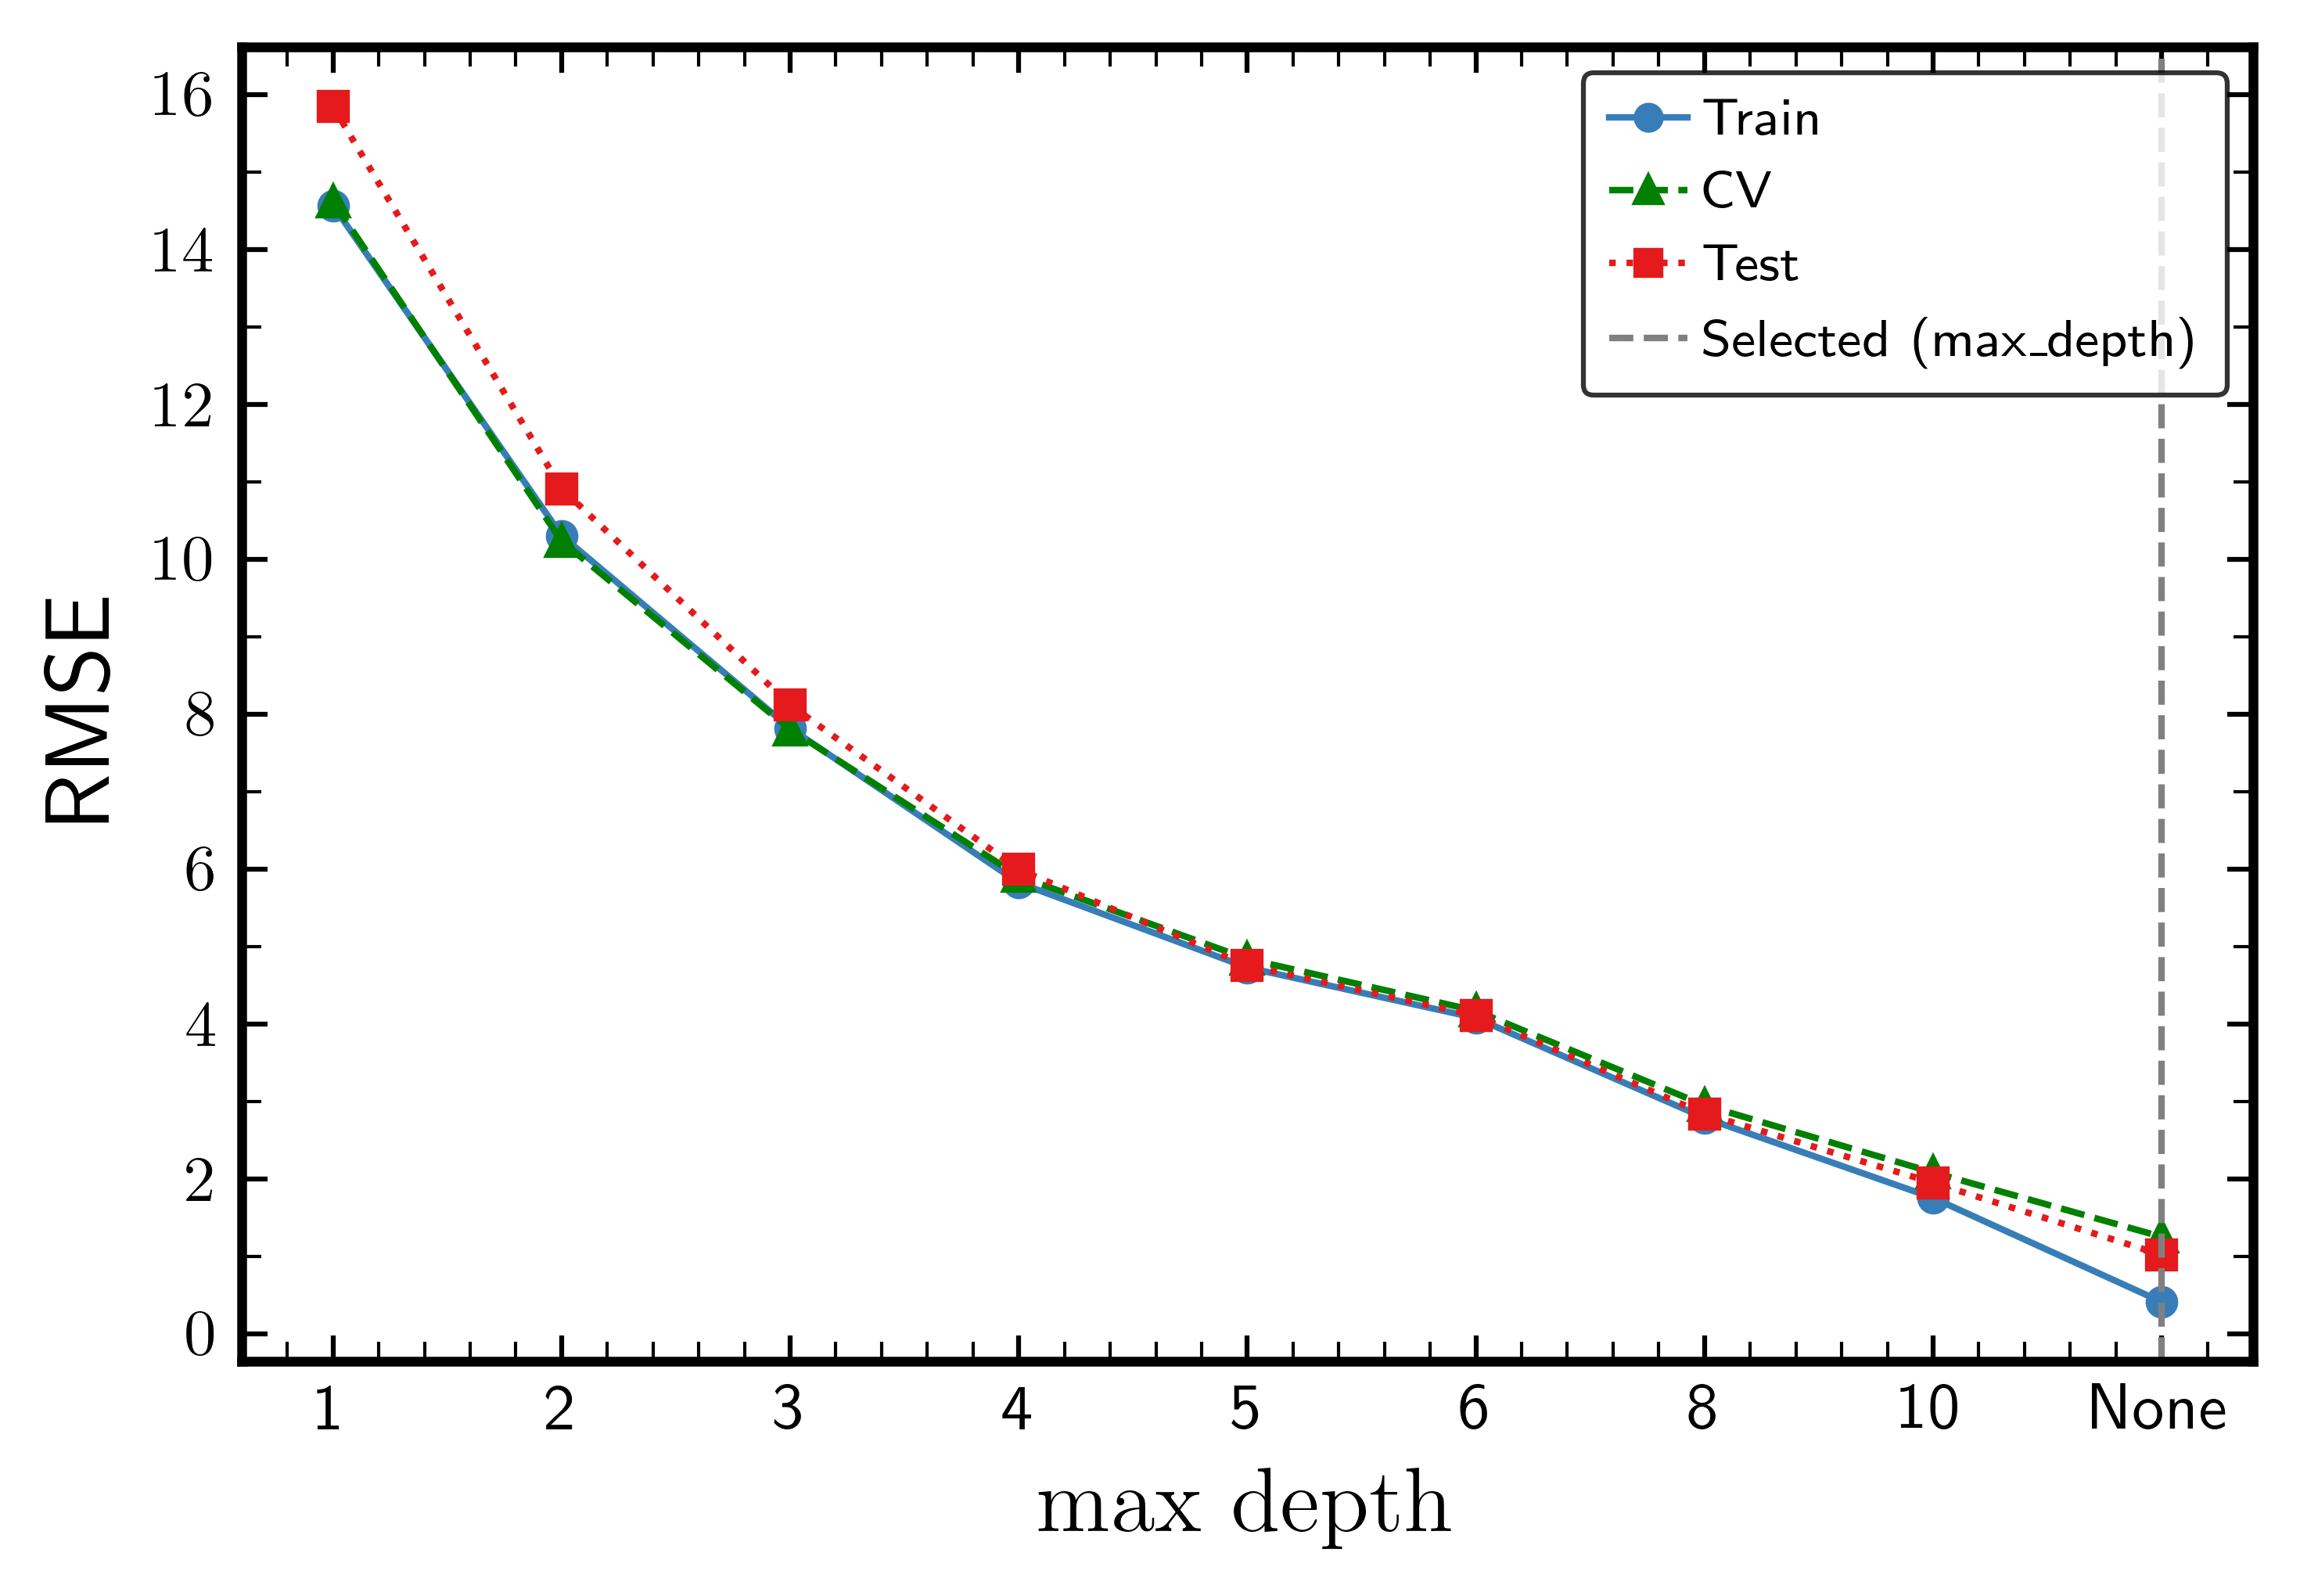

Saved: RF_P_bubble_max_depth_convergence


In [8]:
# max_depth convergence: RMSE vs tree depth
# Hyperparameter comparison uses CV RMSE; test RMSE is shown only as a holdout reference.

depth_checkpoints = [1, 2, 3, 4, 5, 6, 8, 10, None]
train_rmse_depth = []
cv_rmse_depth    = []
test_rmse_depth  = []

for depth in depth_checkpoints:
    _depth_model = RandomForestRegressor(
        n_estimators=Trees,
        max_depth=depth,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=SEED,
        n_jobs=N_JOBS,
    )
    _depth_model.fit(X_train, y_train)
    train_rmse_depth.append(np.sqrt(mean_squared_error(y_train, _depth_model.predict(X_train))))
    test_rmse_depth.append( np.sqrt(mean_squared_error(y_test,  _depth_model.predict(X_test))))
    cv_rmse_depth.append(
        -cross_val_score(
            _depth_model, X_train, y_train, cv=5,
            scoring='neg_root_mean_squared_error',
            n_jobs=N_JOBS,
        ).mean()
    )

depth_labels = ["None" if depth is None else str(depth) for depth in depth_checkpoints]
x_depth = np.arange(len(depth_labels))

fig, ax = ps.plot_init(w=5, h=3.5)
ax.plot(x_depth, train_rmse_depth, marker='o', markersize=ps.markersize, lw=ps.linewidth,
        color=ps.colors[2], label='Train')
ax.plot(x_depth, cv_rmse_depth, marker='^', markersize=ps.markersize, lw=ps.linewidth,
        color=ps.colors[1], label='CV')
ax.plot(x_depth, test_rmse_depth,  marker='s', markersize=ps.markersize, lw=ps.linewidth,
        color=ps.colors[0], label='Test')

selected_depth = "None" if rf_model.max_depth is None else str(rf_model.max_depth)
if selected_depth in depth_labels:
    ax.axvline(depth_labels.index(selected_depth), ls='--', color='gray', lw=ps.linewidth,
               label='Selected (max_depth)')

ax.set_xticks(x_depth)
ax.set_xticklabels(depth_labels)
ax.set_xlabel(r"$\mathrm{max\ depth}$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"RMSE", fontsize=ps.label_fontsize)
ax.minorticks_on()
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='minor', length=3)
ps.style_legend(ax, loc='upper right')
plt.tight_layout()
ps.save_plot(fig, f"RF_{target}_max_depth_convergence", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: RF_{target}_max_depth_convergence")


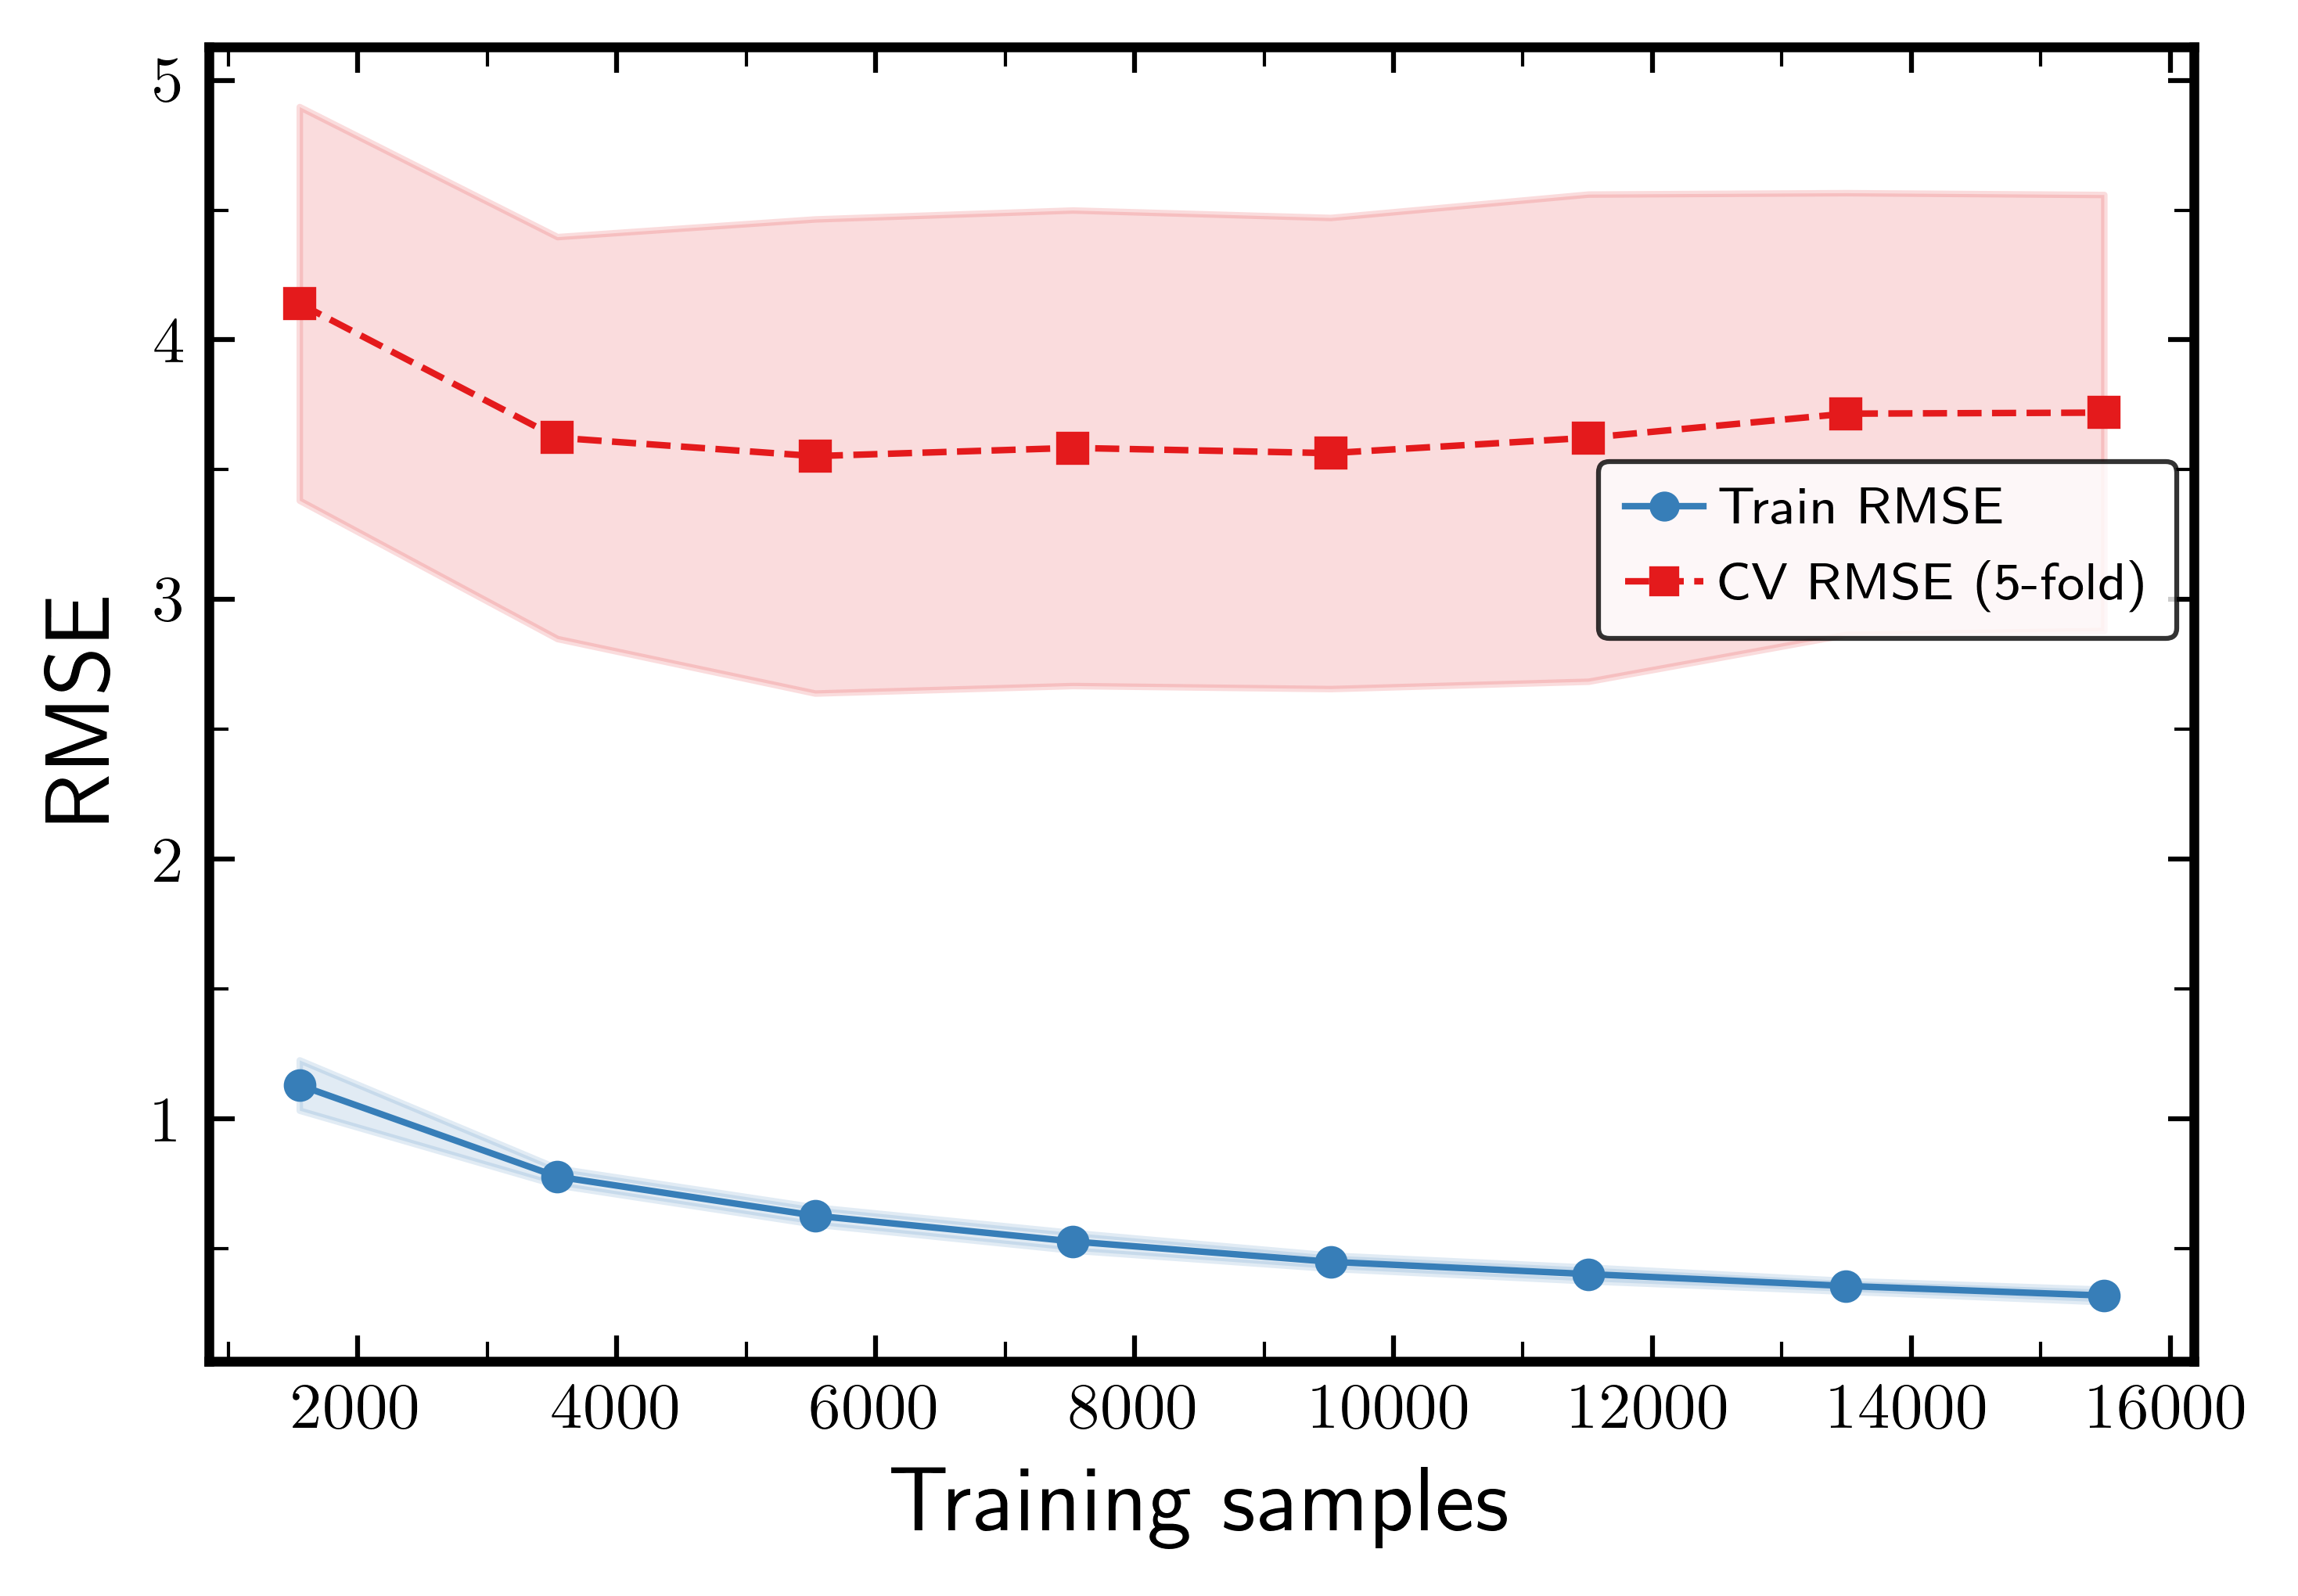

Saved: RF_P_bubble_learning_curve


In [9]:
# Learning curve — evaluates whether more data would improve the model
# Uses n_estimators=100 for speed; 5-fold CV across 8 training-set fractions

lc_estimator = RandomForestRegressor(
    n_estimators=100, max_depth=None, min_samples_split=2,
    min_samples_leaf=1, random_state=SEED, n_jobs=N_JOBS
)

train_sizes, train_scores, val_scores = learning_curve(
    lc_estimator, X, y, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='neg_root_mean_squared_error',
    n_jobs=N_JOBS, shuffle=True, random_state=SEED
)

train_rmse_lc = -train_scores.mean(axis=1)
val_rmse_lc   = -val_scores.mean(axis=1)
train_std_lc  =  train_scores.std(axis=1)
val_std_lc    =  val_scores.std(axis=1)

fig, ax = ps.plot_init(w=5, h=3.5)
ax.plot(train_sizes, train_rmse_lc, marker='o', markersize=ps.markersize, lw=ps.linewidth,
        color=ps.colors[2], label='Train RMSE')
ax.fill_between(train_sizes, train_rmse_lc - train_std_lc, train_rmse_lc + train_std_lc,
                color=ps.colors[2], alpha=0.15)
ax.plot(train_sizes, val_rmse_lc,   marker='s', markersize=ps.markersize, lw=ps.linewidth,
        color=ps.colors[0], label='CV RMSE (5-fold)')
ax.fill_between(train_sizes, val_rmse_lc - val_std_lc, val_rmse_lc + val_std_lc,
                color=ps.colors[0], alpha=0.15)
ax.set_xlabel(r"Training samples", fontsize=ps.label_fontsize)
ax.set_ylabel(r"RMSE", fontsize=ps.label_fontsize)
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='minor', length=3)
ps.style_legend(ax, loc=(0.7,0.55))
plt.tight_layout()
ps.save_plot(fig, f"RF_{target}_learning_curve", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: RF_{target}_learning_curve")


In [10]:
# Error breakdown by temperature quartile (test set)
test_analysis = pd.DataFrame({
    "temperature":   X_test["temperature"].values,
    "actual":        y_test.values,
    "predicted":     y_test_pred,
})
test_analysis["abs_error"]     = np.abs(test_analysis["actual"] - test_analysis["predicted"])
test_analysis["squared_error"] = (test_analysis["actual"] - test_analysis["predicted"]) ** 2
test_analysis["pct_error"]     = test_analysis["abs_error"] / np.abs(test_analysis["actual"]) * 100
test_analysis["temp_bin"]      = pd.qcut(
    test_analysis["temperature"], q=4,
    labels=["Q1 (coldest)", "Q2", "Q3", "Q4 (hottest)"]
)

bin_stats = test_analysis.groupby("temp_bin", observed=True).agg(
    Count    = ("abs_error",     "count"),
    Temp_min = ("temperature",   "min"),
    Temp_max = ("temperature",   "max"),
    MAE      = ("abs_error",     "mean"),
    RMSE     = ("squared_error", lambda x: np.sqrt(x.mean())),
    MAPE_pct = ("pct_error",     "mean"),
).reset_index()

print(f"Error Breakdown by Temperature Quartile — {target} (Test set)\n")
print(bin_stats.to_string(index=False, float_format="{:.4f}".format))

bin_stats.to_csv(os.path.join(OUTPUT_FOLDER, f"RF_{target}_error_by_temp_bin.csv"), index=False)
print(f"\nSaved: RF_{target}_error_by_temp_bin.csv")

Error Breakdown by Temperature Quartile — P_bubble (Test set)

    temp_bin  Count  Temp_min  Temp_max    MAE   RMSE  MAPE_pct
Q1 (coldest)    736  200.0000  220.0000 0.5055 1.3110    1.3569
          Q2    769  225.0000  245.0000 0.4341 0.6557    1.5887
          Q3    720  250.0000  270.0000 0.6369 1.0029    1.5220
Q4 (hottest)    679  275.0000  300.0000 0.6550 1.0042    1.0616

Saved: RF_P_bubble_error_by_temp_bin.csv


Outlier threshold (3σ): ±1.975897
Test outliers: 145/2904 (4.99%)
Val  outliers: 164/2905  (5.65%)
Saved: RF_P_bubble_outliers.csv (309 rows)
  idx split  source_id  temperature   pressure     actual  predicted  residual
10881  test         56        220.0  54.405531  60.346255  57.646857  2.699398
17152  test         88        250.0  39.822086  49.748103  45.743337  4.004766
19083  test         98        250.0  37.615962  42.656923  40.341817  2.315106
 7328  test         37        275.0  53.993434  60.117388  57.266113  2.851275
15341  test         79        220.0   6.808294 103.464478 106.058692 -2.594214
15066  test         77        275.0  58.523593  58.523693  60.893182 -2.369489
 7855  test         40        250.0  35.952759  35.952859  38.440769 -2.487910
 5572  test         28        270.0  50.577712  50.577812  52.714018 -2.136206
 9684  test         50        200.0  55.556597 121.635785 112.559032  9.076753
 2635  test         13        270.0  34.888515  47.031874  44.945249

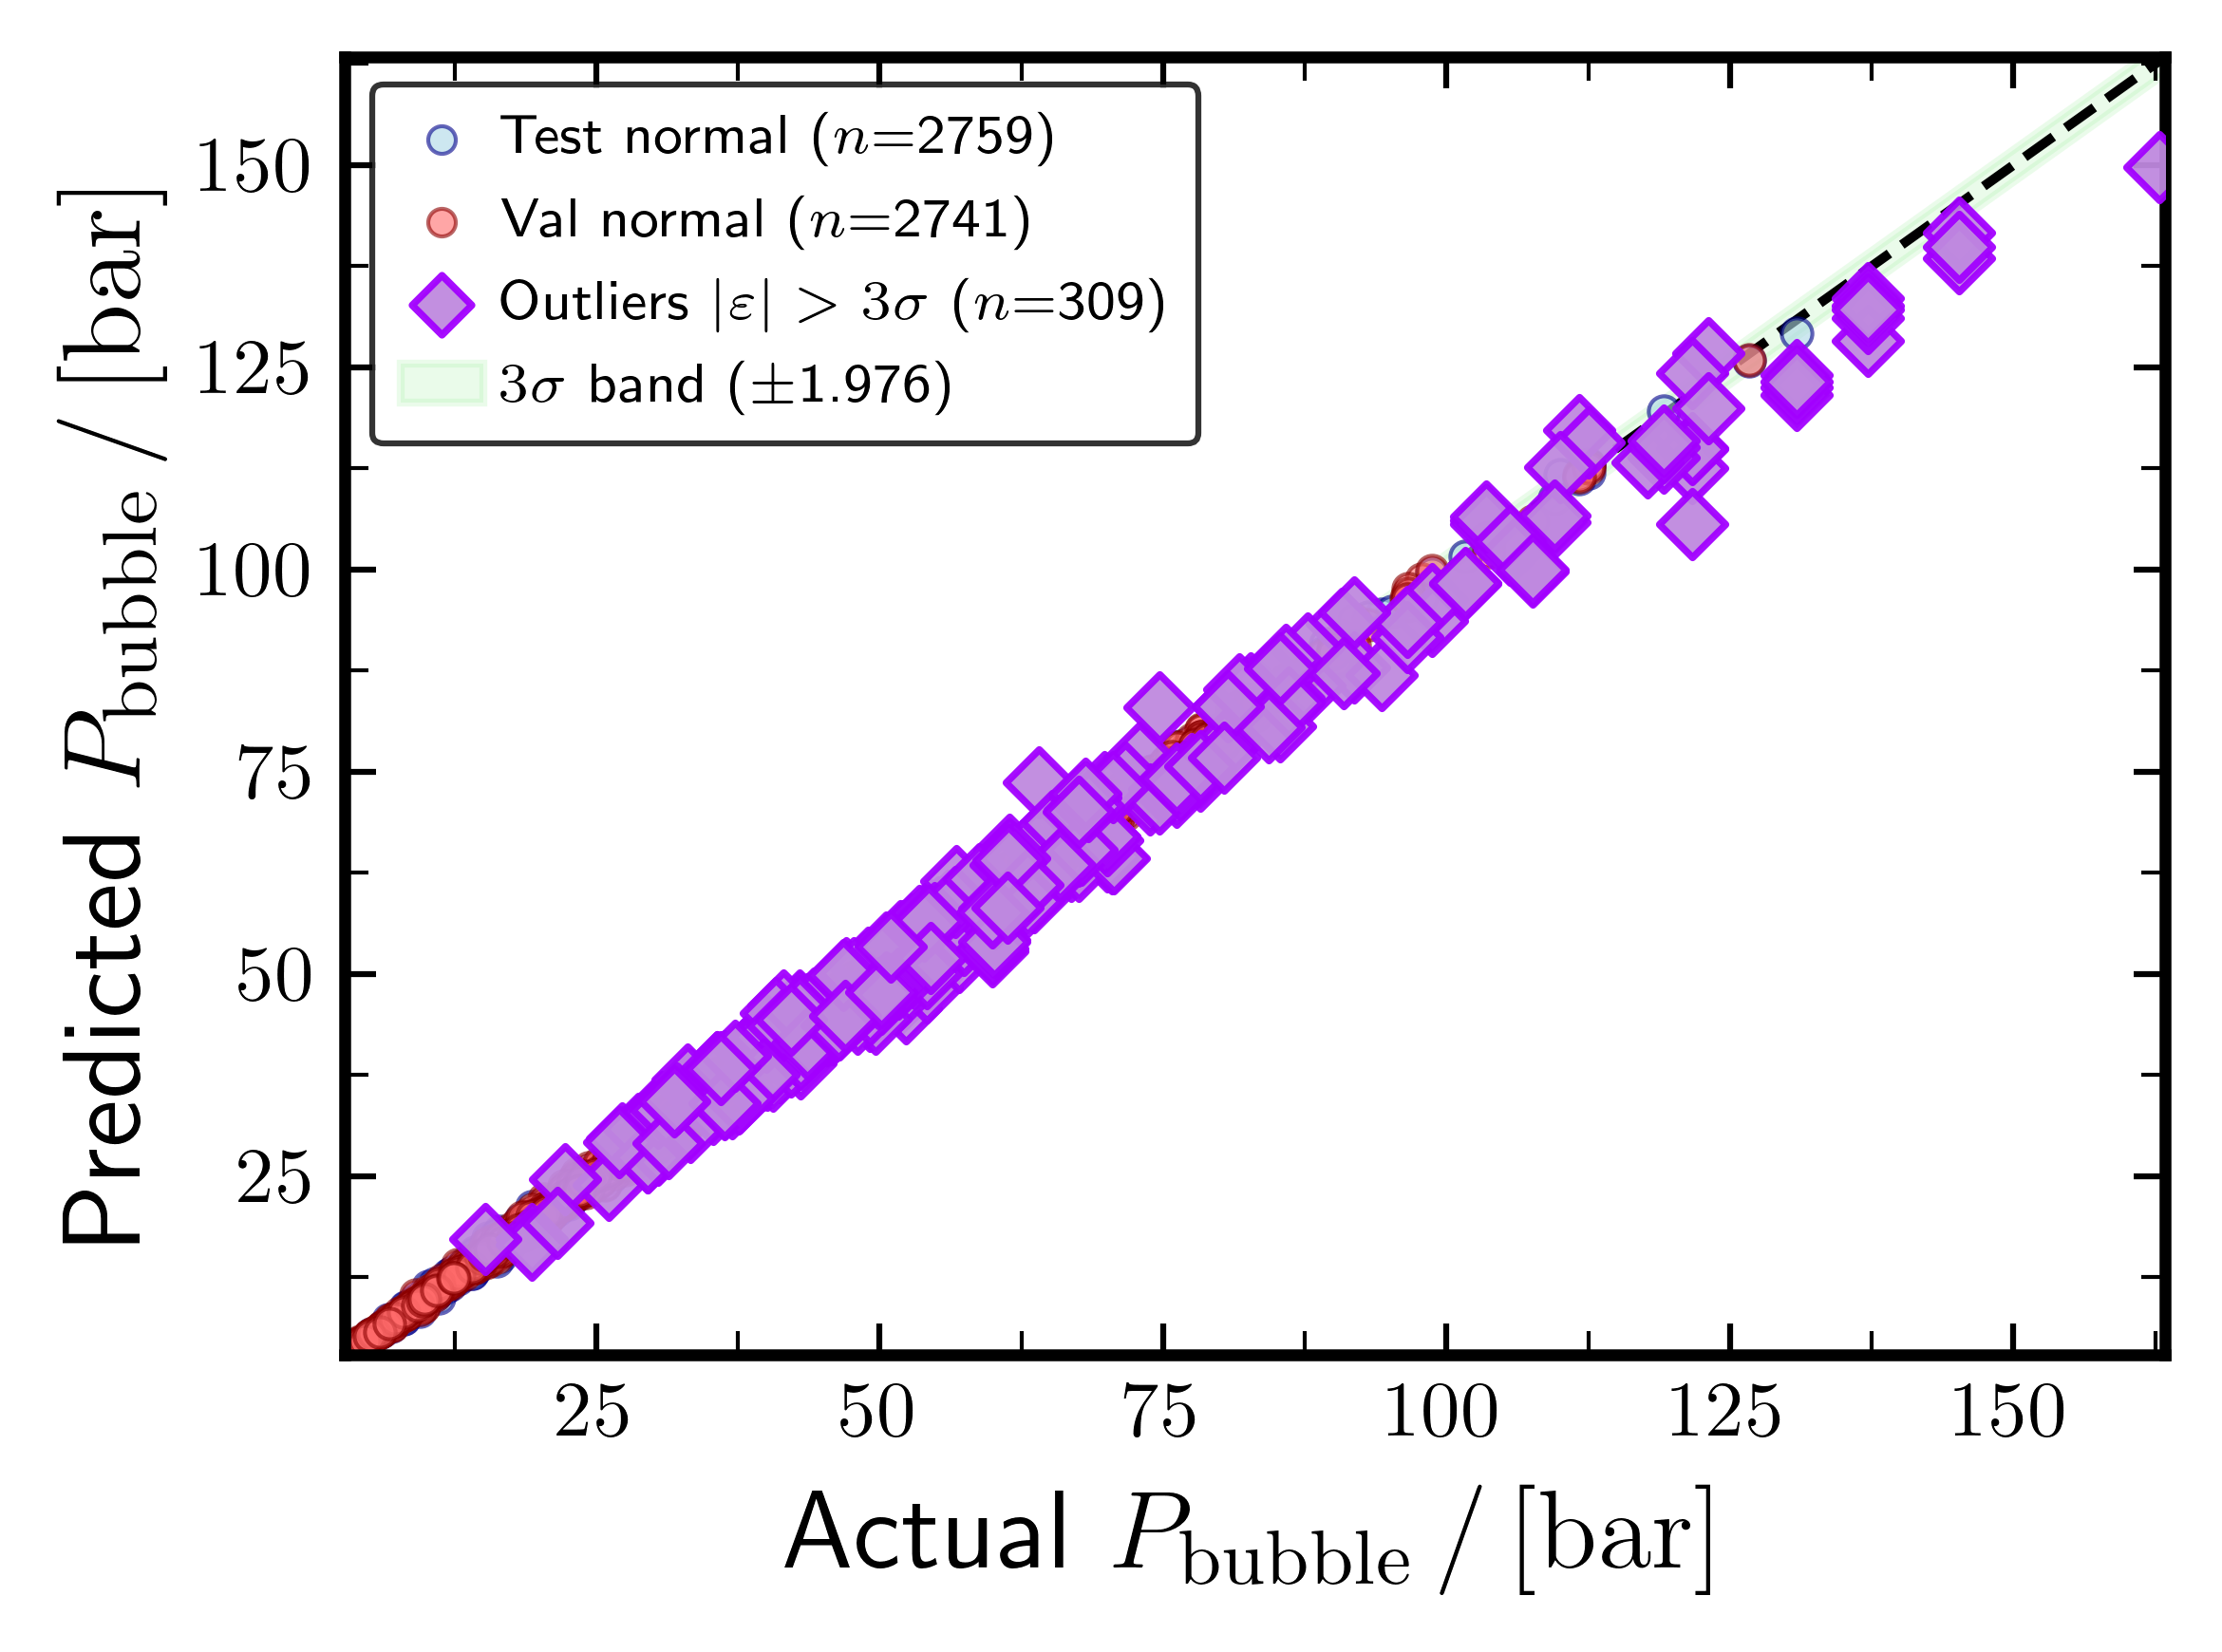

Saved: RF_P_bubble_outlier_parity


In [11]:
# Outlier flagging: test + val samples where |residual| > 3 * global std

all_resids_global = np.concatenate([
    np.asarray(y_train) - y_train_pred,
    np.asarray(y_test)  - y_test_pred,
    np.asarray(y_val)   - y_val_pred,
])
threshold = 3.0 * all_resids_global.std()

test_resids   = np.asarray(y_test) - y_test_pred
val_resids    = np.asarray(y_val)  - y_val_pred
test_out_mask = np.abs(test_resids) > threshold
val_out_mask  = np.abs(val_resids)  > threshold

n_test_out = int(test_out_mask.sum())
n_val_out  = int(val_out_mask.sum())
print(f"Outlier threshold (3\u03c3): \u00b1{threshold:.6f}")
print(f"Test outliers: {n_test_out}/{len(y_test)} ({100*n_test_out/len(y_test):.2f}%)")
print(f"Val  outliers: {n_val_out}/{len(y_val)}  ({100*n_val_out/len(y_val):.2f}%)")

outlier_df = pd.concat([
    pd.DataFrame({
        "idx":         y_test.index[test_out_mask],
        "split":       "test",
        "source_id":   df.loc[y_test.index[test_out_mask], "source_id"].values,
        "temperature": df.loc[y_test.index[test_out_mask], "temperature"].values,
        "pressure":    df.loc[y_test.index[test_out_mask], "pressure"].values,
        "actual":      np.asarray(y_test)[test_out_mask],
        "predicted":   y_test_pred[test_out_mask],
        "residual":    test_resids[test_out_mask],
    }),
    pd.DataFrame({
        "idx":         y_val.index[val_out_mask],
        "split":       "val",
        "source_id":   df.loc[y_val.index[val_out_mask], "source_id"].values,
        "temperature": df.loc[y_val.index[val_out_mask], "temperature"].values,
        "pressure":    df.loc[y_val.index[val_out_mask], "pressure"].values,
        "actual":      np.asarray(y_val)[val_out_mask],
        "predicted":   y_val_pred[val_out_mask],
        "residual":    val_resids[val_out_mask],
    }),
], ignore_index=True)
outlier_df.to_csv(os.path.join(OUTPUT_FOLDER, f"RF_{target}_outliers.csv"), index=False)
print(f"Saved: RF_{target}_outliers.csv ({len(outlier_df)} rows)")
print(outlier_df.to_string(index=False))

# Parity plot highlighting outliers
fig, ax = ps.plot_init()

for y_true_sp, y_pred_sp, out_mask, fc, ec, lbl in [
    (y_test, y_test_pred, test_out_mask, "lightblue", "darkblue", "Test"),
    (y_val,  y_val_pred,  val_out_mask,  "#FF6B6B",   "darkred",  "Val"),
]:
    norm = ~out_mask
    ax.scatter(
        np.asarray(y_true_sp)[norm], y_pred_sp[norm],
        alpha=0.6, s=15, facecolors=fc, edgecolors=ec,
        linewidths=0.5, zorder=2,
        label=rf"{lbl} normal ($n$={int(norm.sum())})",
    )

all_out_true = np.concatenate([np.asarray(y_test)[test_out_mask], np.asarray(y_val)[val_out_mask]])
all_out_pred = np.concatenate([y_test_pred[test_out_mask], y_val_pred[val_out_mask]])
if len(all_out_true) > 0:
    ax.scatter(
        all_out_true, all_out_pred,
        alpha=0.95, s=35, facecolors="#BF89DF", edgecolors="#A200FF",
        linewidths=0.9, marker='D', zorder=4,
        label=rf"Outliers $|\varepsilon|>3\sigma$ ($n$={len(all_out_true)})",
    )
all_vals = np.concatenate([np.asarray(y_test), np.asarray(y_val), y_test_pred, y_val_pred])
lims     = [all_vals.min() - 0.5, all_vals.max() + 0.5]
x_line   = np.array(lims)
ax.fill_between(x_line, x_line - threshold, x_line + threshold,
                color="lightgreen", alpha=0.18, zorder=0,
                label=rf"$3\sigma$ band ($\pm${threshold:.3f})")
ax.plot(lims, lims, "k--", lw=1.2, zorder=1)
ax.set_xlim(lims)
ax.set_ylim(lims)

target_label_str = ps.label_map.get(target.lower(), target)
ax.set_xlabel(f"Actual {target_label_str}", fontsize=ps.label_fontsize)
ax.set_ylabel(f"Predicted {target_label_str}", fontsize=ps.label_fontsize)
ps.apply_axis_style(ax)
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='minor', length=3)
ps.style_legend(ax, loc='upper left', fontsize=ps.label_fontsize * 0.5)
plt.tight_layout()
ps.save_plot(fig, f"RF_{target}_outlier_parity", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: RF_{target}_outlier_parity")

In [12]:
# 5-fold cross-validation
cv_r2_scores   = cross_val_score(rf_model, X, y, cv=5, scoring='r2', n_jobs=N_JOBS)
cv_rmse_scores = -cross_val_score(rf_model, X, y, cv=5, scoring='neg_root_mean_squared_error', n_jobs=N_JOBS)
cv_mae_scores  = -cross_val_score(rf_model, X, y, cv=5, scoring='neg_mean_absolute_error', n_jobs=N_JOBS)
cv_mape_scores = -cross_val_score(rf_model, X, y, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=N_JOBS)

print(f"Cross-Validation R² Scores:   {cv_r2_scores}")
print(f"Mean CV R²:    {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std() * 2:.6f})")
print(f"\nCross-Validation RMSE Scores: {cv_rmse_scores}")
print(f"Mean CV RMSE:  {cv_rmse_scores.mean():.6f} (+/- {cv_rmse_scores.std() * 2:.6f})")
print(f"\nCross-Validation MAE Scores:  {cv_mae_scores}")
print(f"Mean CV MAE:   {cv_mae_scores.mean():.6f} (+/- {cv_mae_scores.std() * 2:.6f})")
print(f"\nCross-Validation MAPE Scores: {cv_mape_scores * 100}")
print(f"Mean CV MAPE:  {cv_mape_scores.mean() * 100:.4f}% (+/- {cv_mape_scores.std() * 2 * 100:.4f}%)")

Cross-Validation R² Scores:   [0.97262358 0.95406061 0.98396704 0.95790737 0.97710249]
Mean CV R²:    0.969132 (+/- 0.022785)

Cross-Validation RMSE Scores: [3.33211749 5.0097814  2.80120524 4.25085508 2.89303138]
Mean CV RMSE:  3.657398 (+/- 1.698061)

Cross-Validation MAE Scores:  [2.21387346 3.36016573 1.86773138 2.71536319 2.12475472]
Mean CV MAE:   2.456378 (+/- 1.057995)

Cross-Validation MAPE Scores: [ 8.1094125  12.20517881  6.00463893  7.85793888  6.35027765]
Mean CV MAPE:  8.1055% (+/- 4.4148%)


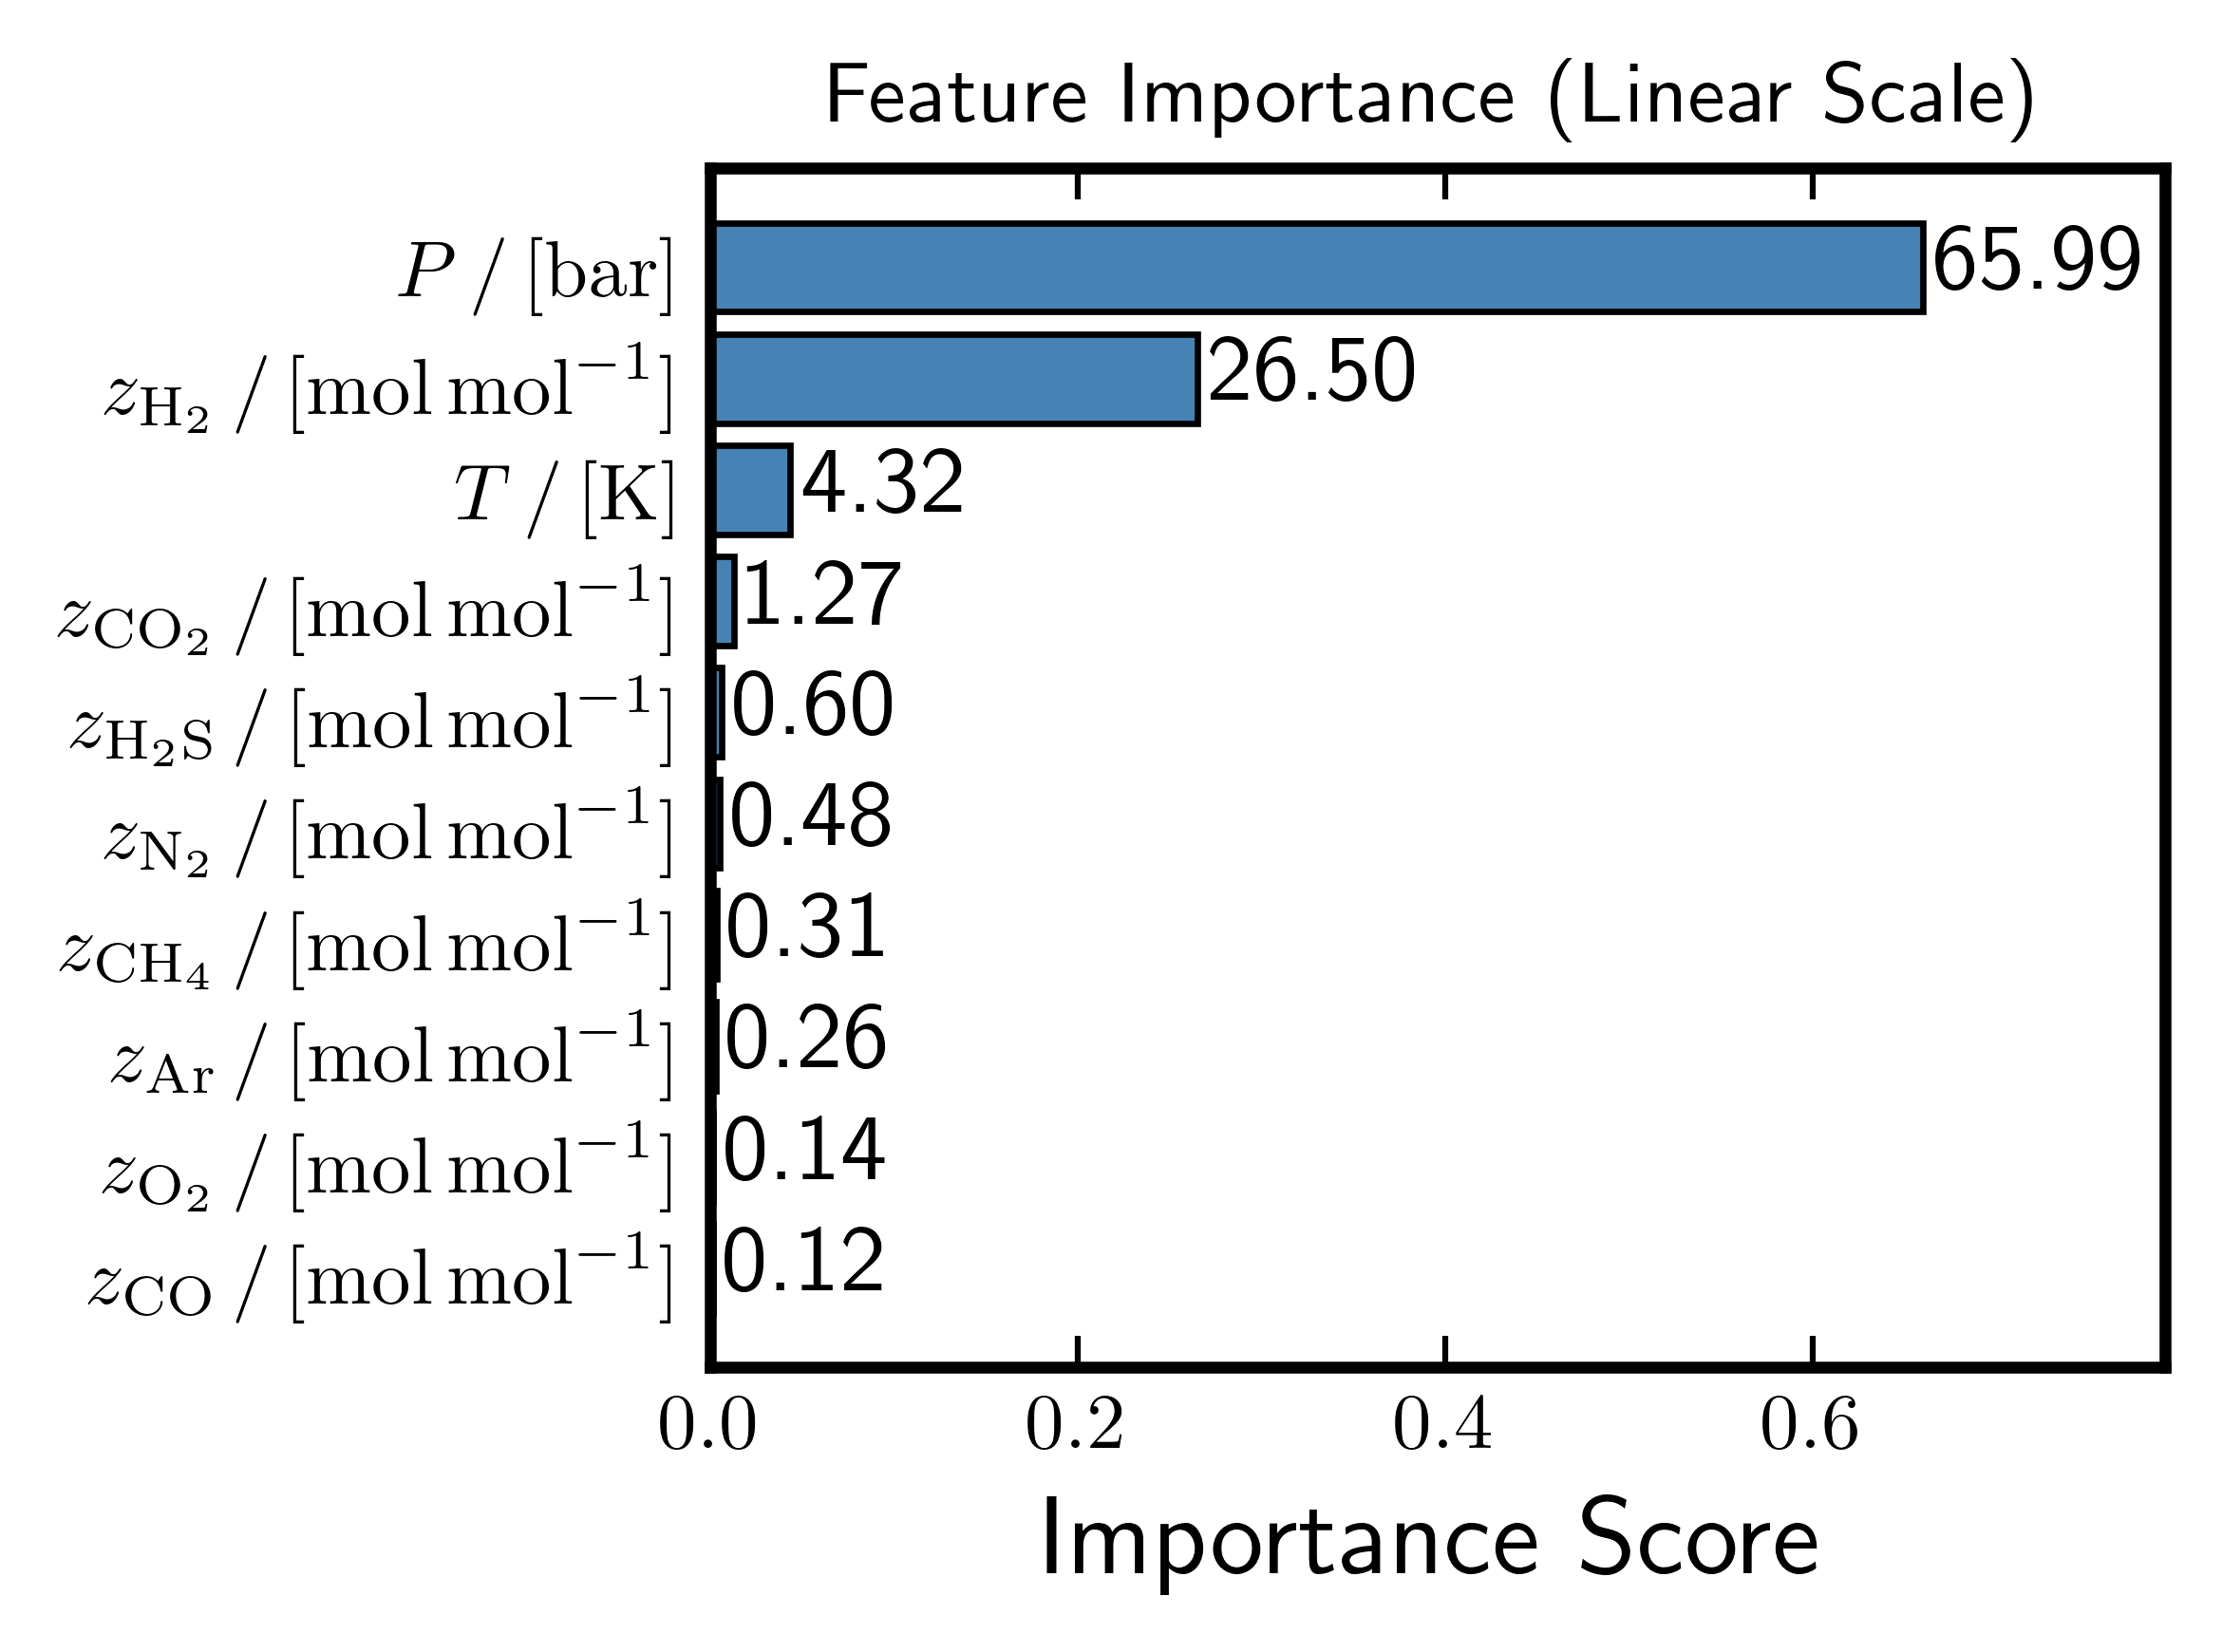

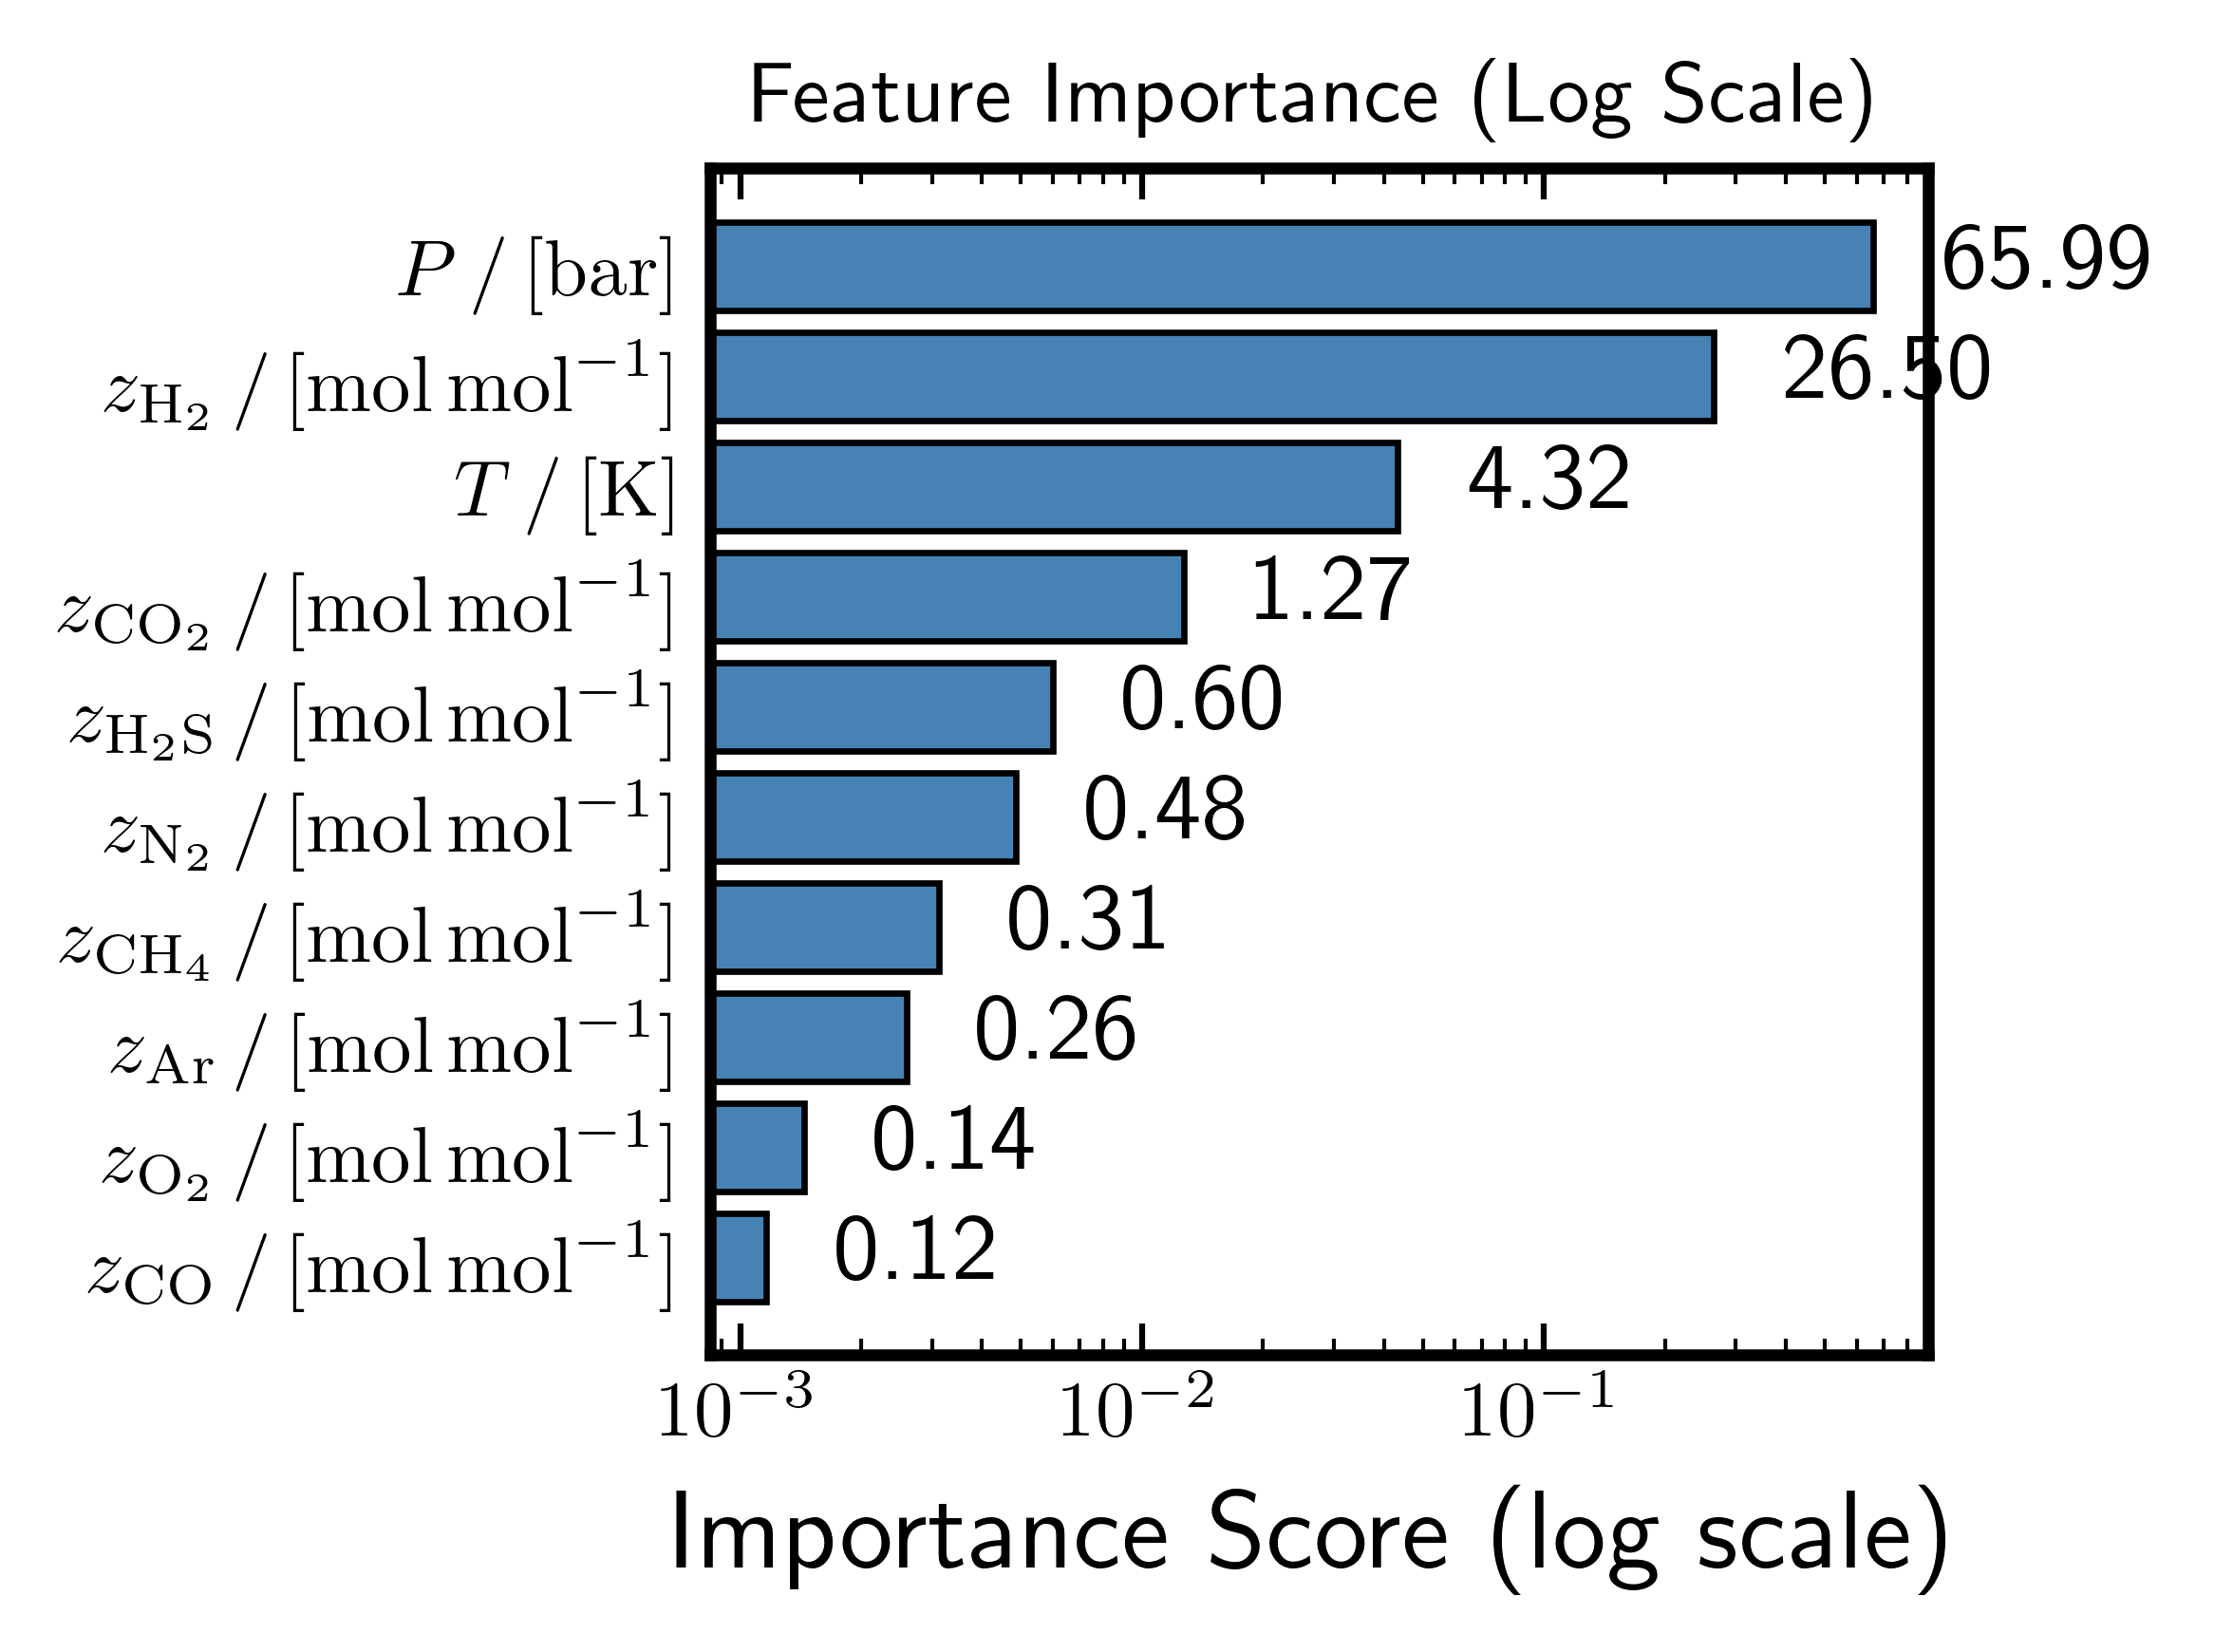

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: title={'center': 'Feature Importance (Log Scale)'}, xlabel='Importance Score (log scale)'>)

In [13]:
# Initialize MLPostprocessing
post = MLPostprocessing(
    y_true=y_test,
    y_pred=y_test_pred,
    target="P_bubble",
    feature_importances=rf_model.feature_importances_,
    feature_names=features,
    datasets={
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)

# Plot feature importance (Linear Scale)
post.plot_feature_importance(scale="linear", color="steelblue", save_path="RF_P_bubble_feature_importance_linear", folder=OUTPUT_FOLDER)
post.plot_feature_importance(scale="log", color="steelblue", save_path="RF_P_bubble_feature_importance_log", folder=OUTPUT_FOLDER)


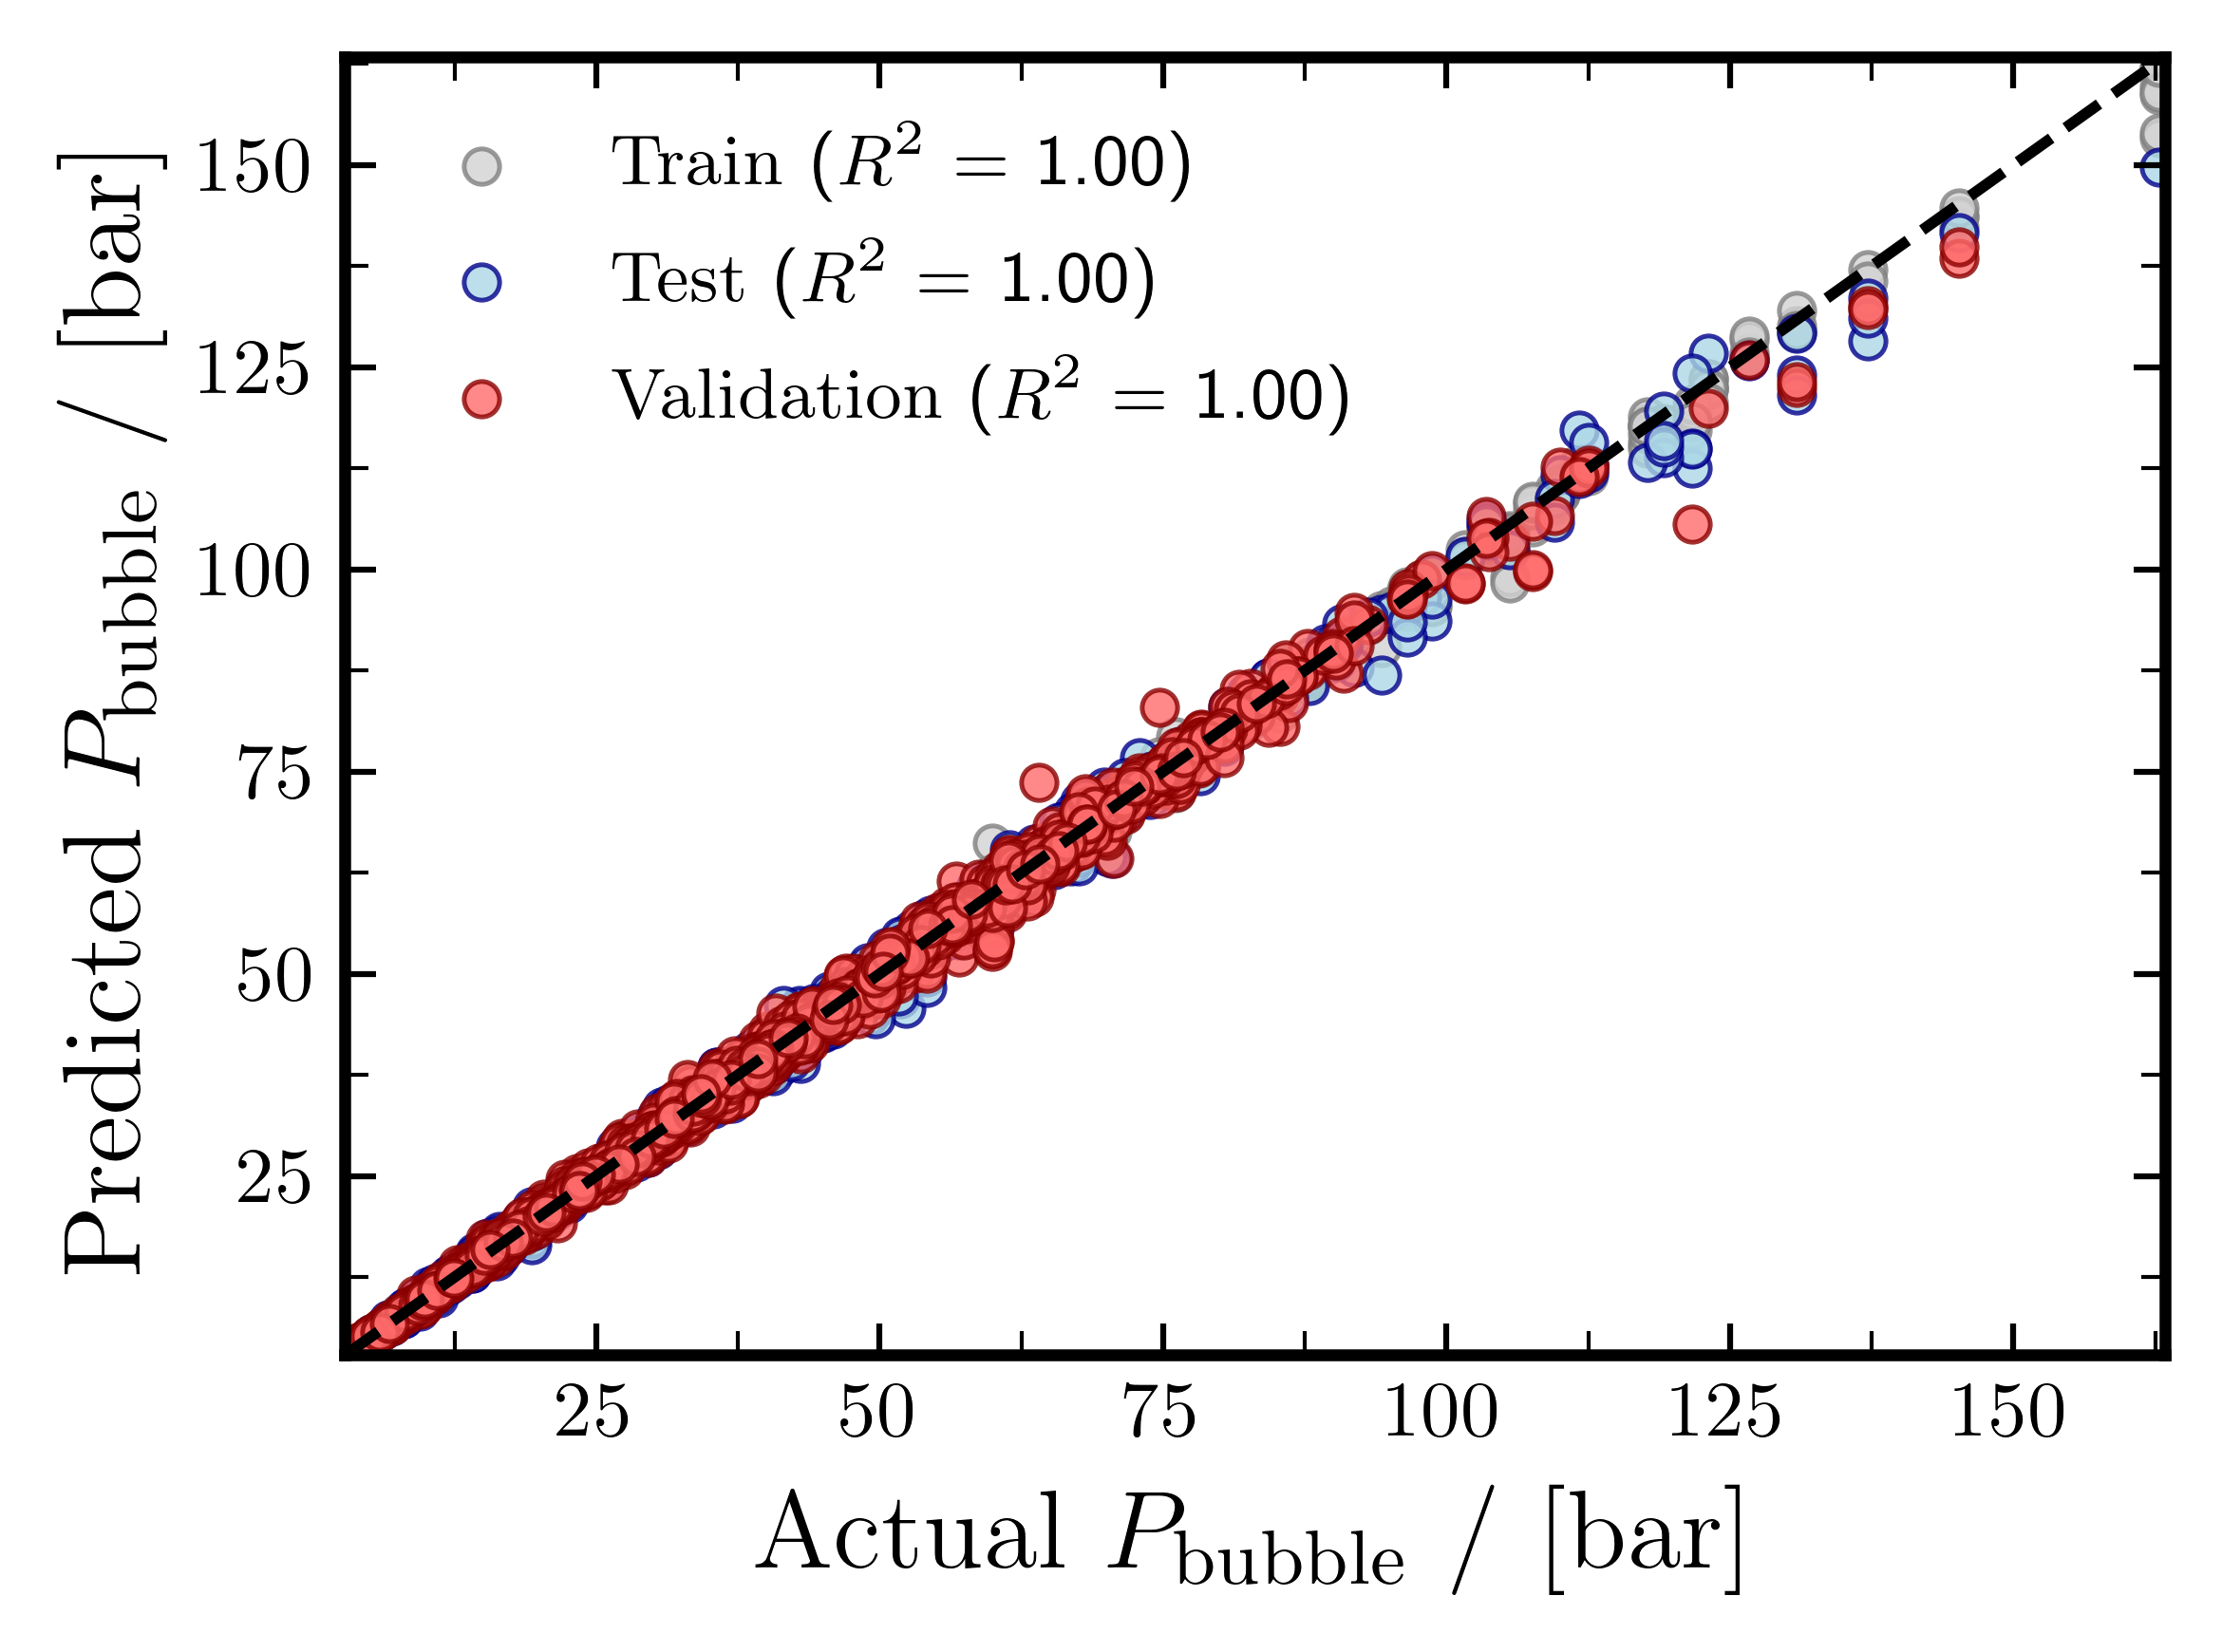

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{Actual}$ $P_{\\mathrm{bubble}}$ / $[\\mathrm{bar}]$', ylabel='$\\mathrm{Predicted}$ $P_{\\mathrm{bubble}}$ / $[\\mathrm{bar}]$'>)

In [14]:
# Parity plot
post.plot_parity(model_name="Random Forest", save_path="RF_P_bubble_parity_plot", folder=OUTPUT_FOLDER,
                #  cv_r2=cv_r2_scores.mean(), cv_rmse=cv_rmse_scores.mean()
                 )

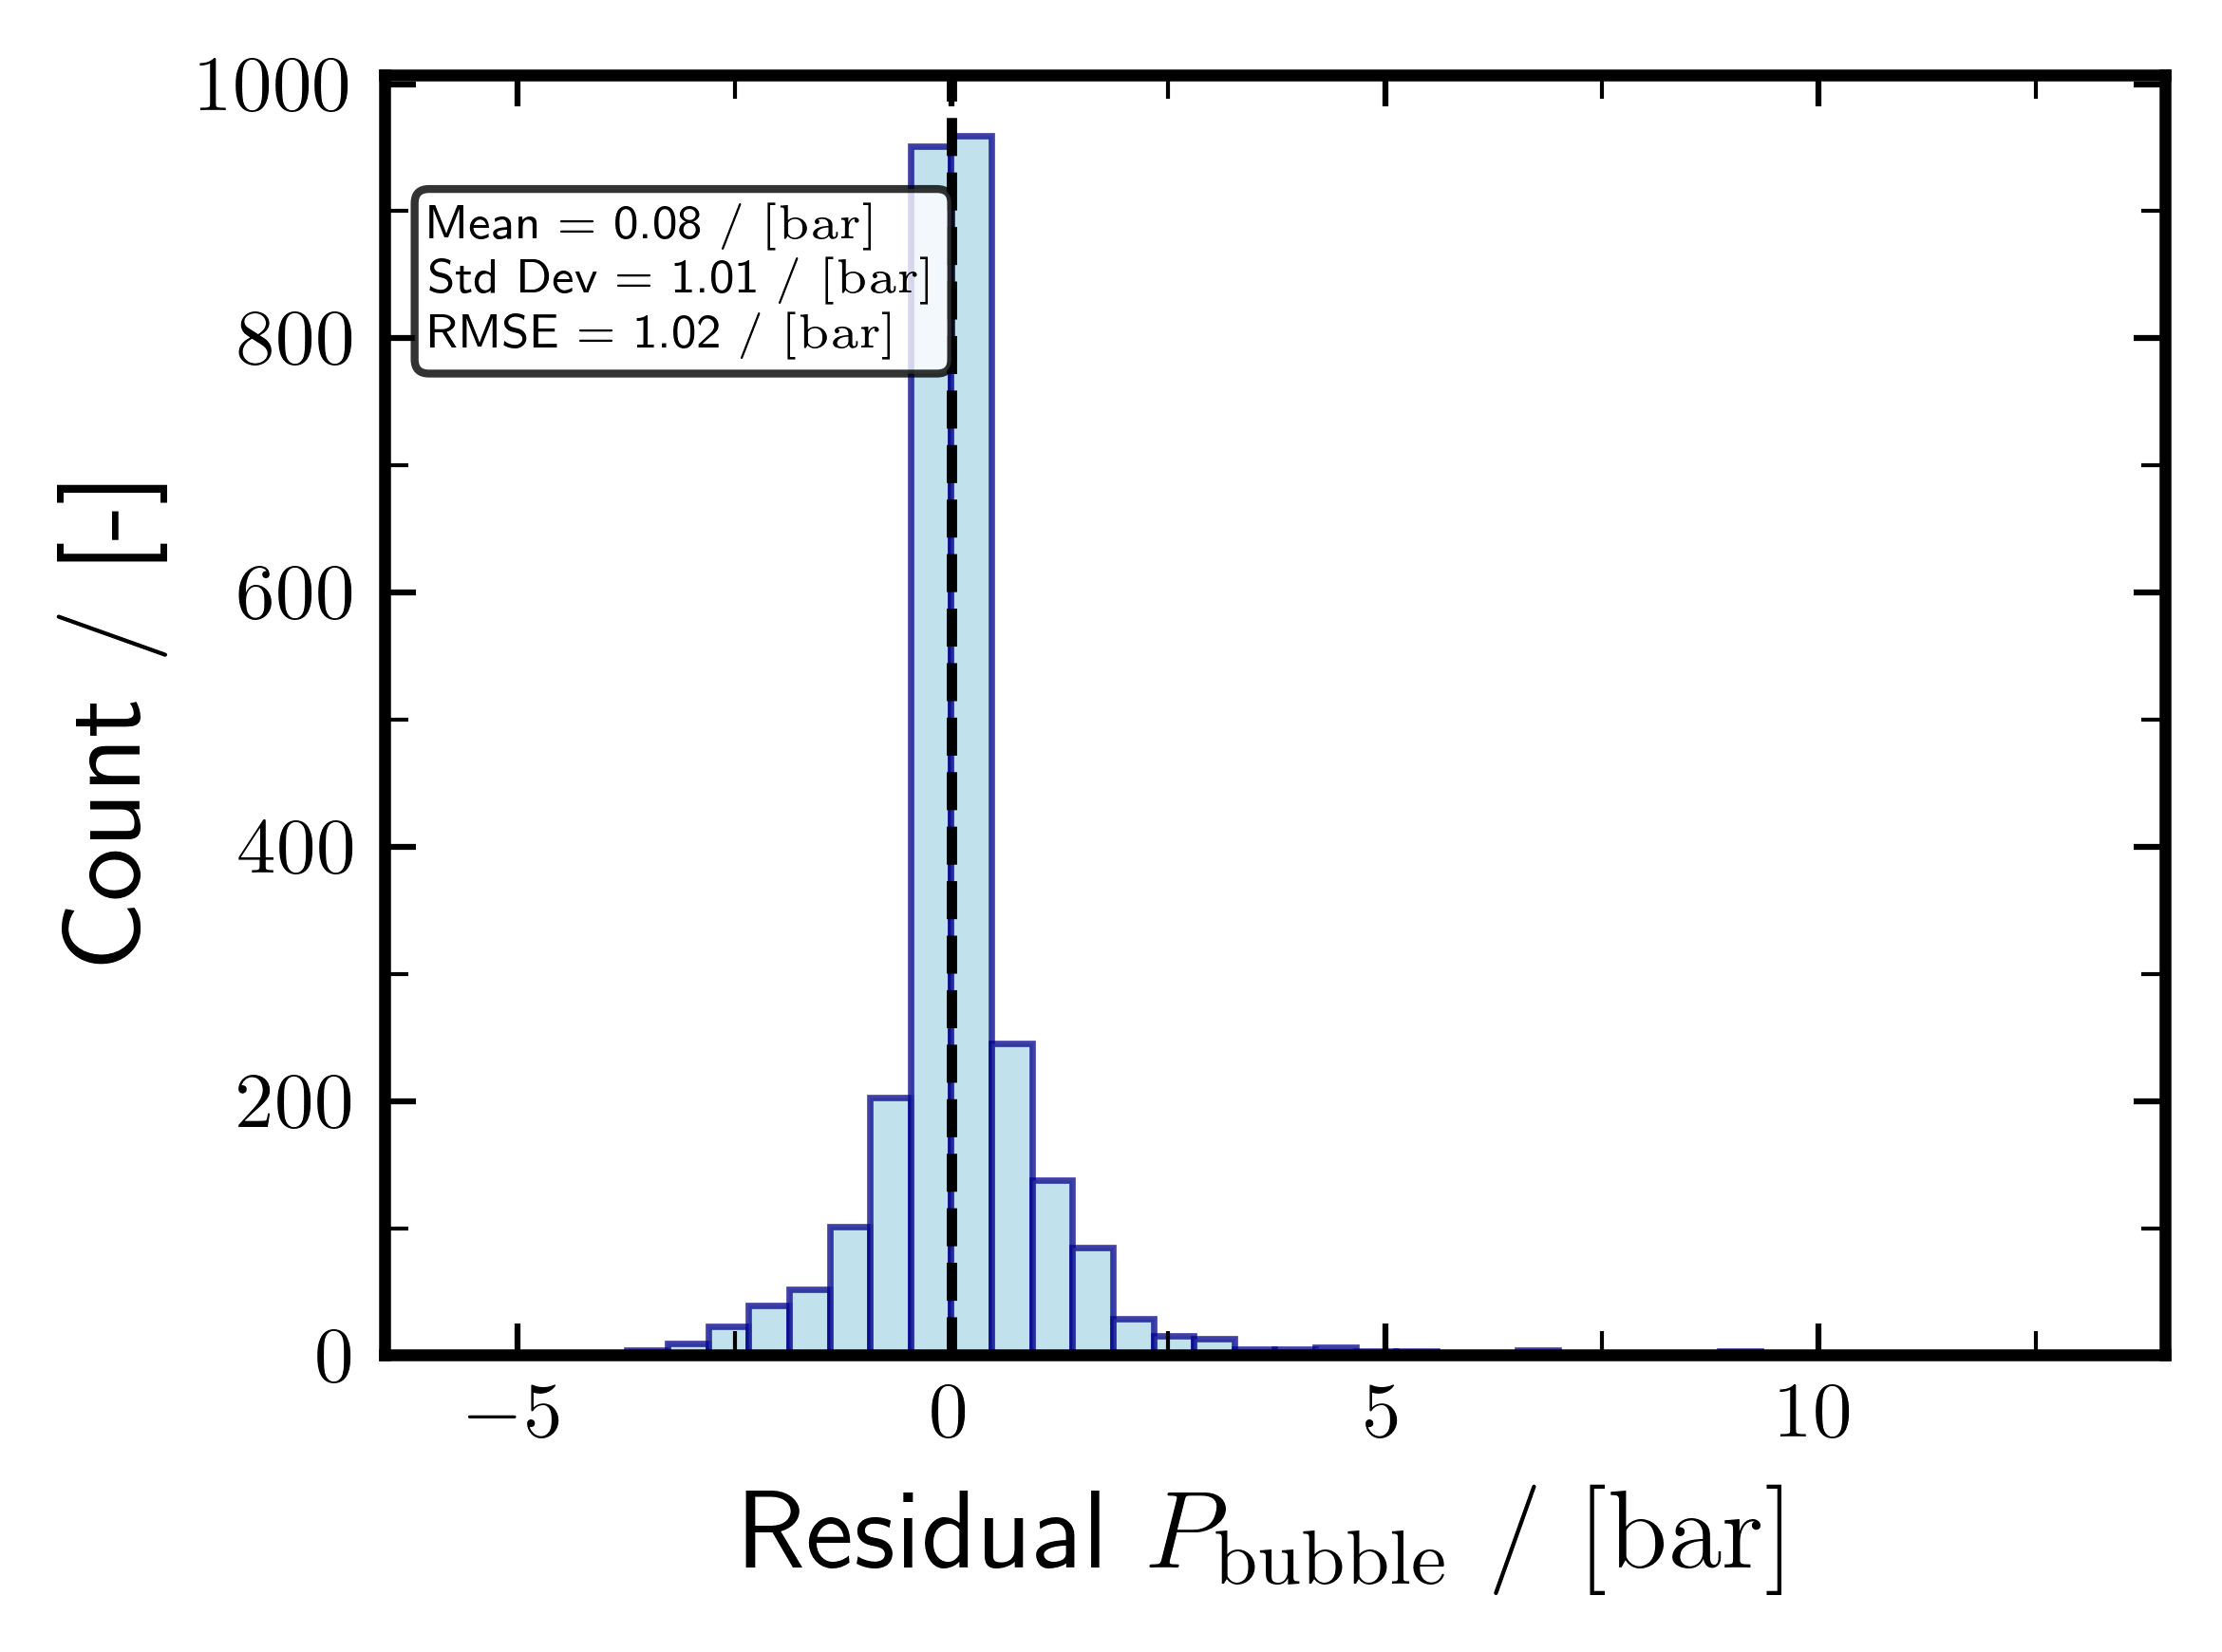

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Residual $P_{\\mathrm{bubble}}$ / $[\\mathrm{bar}]$', ylabel='Count / [-]'>)

In [15]:
# Residual distribution
post.plot_residual_distribution(save_path="RF_P_bubble_residual_distribution", folder=OUTPUT_FOLDER,
                                # cv_r2=cv_r2_scores.mean(), cv_rmse=cv_rmse_scores.mean()
                                )

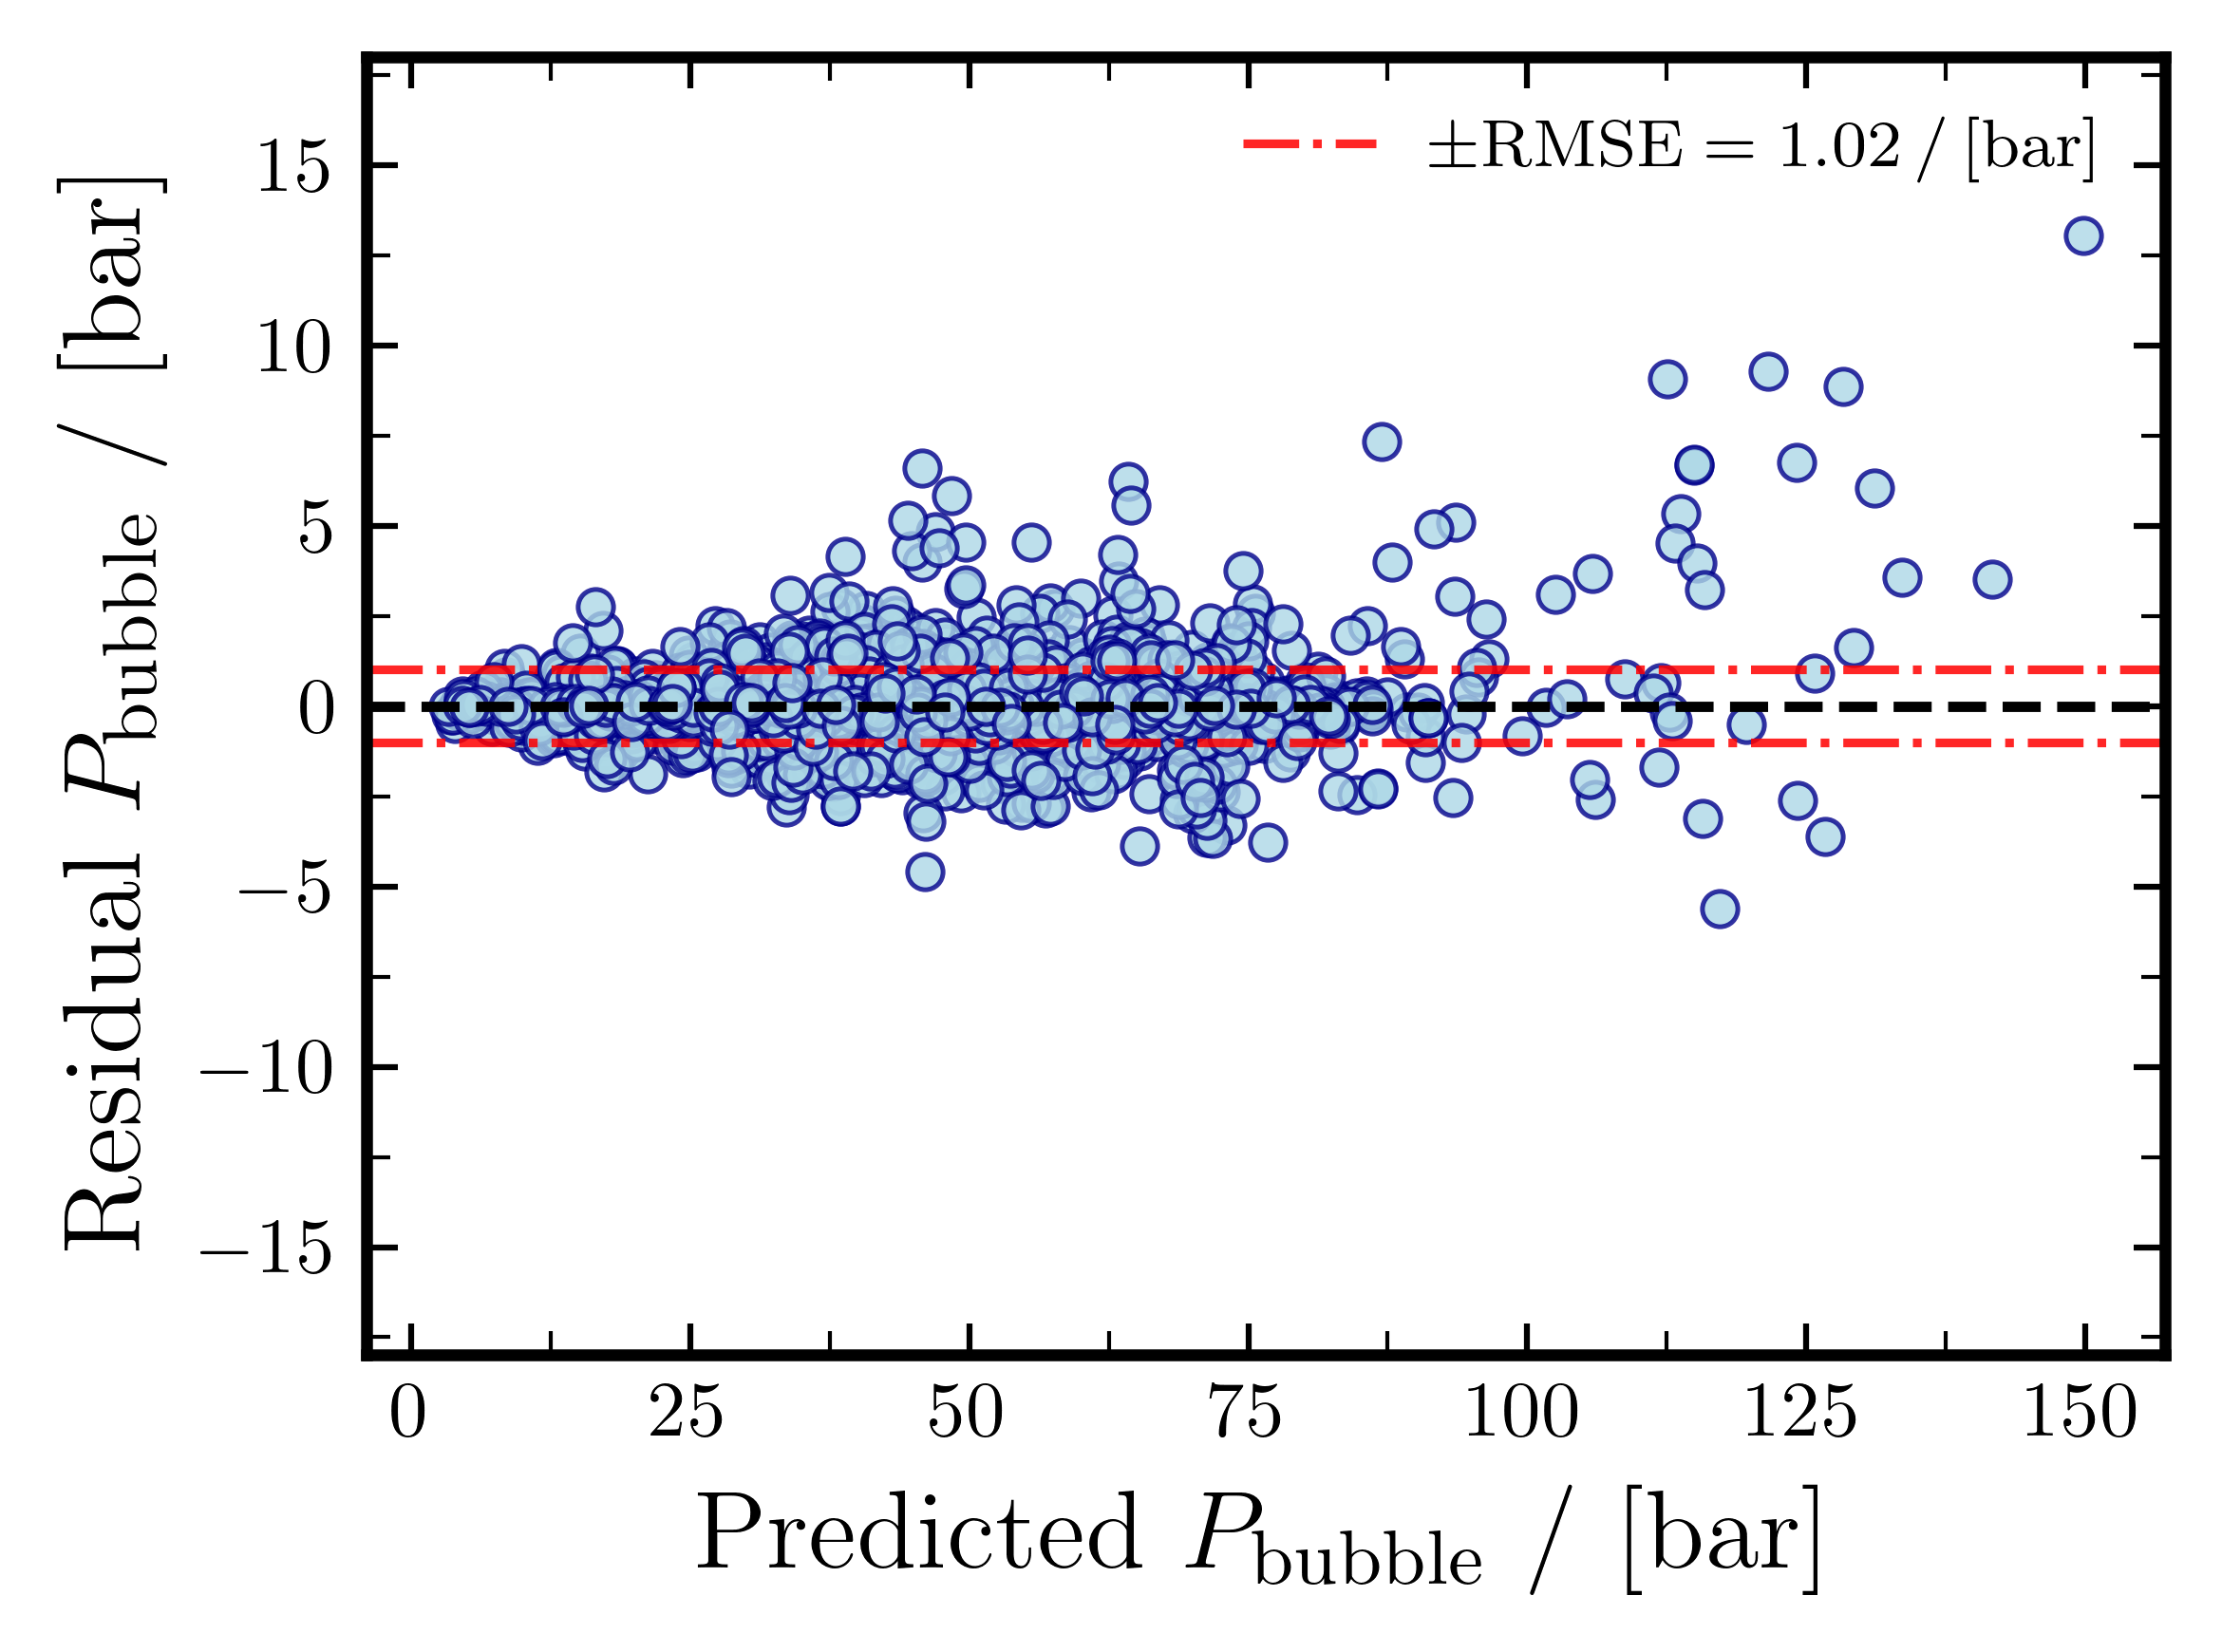

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{Predicted}$ $P_{\\mathrm{bubble}}$ / $[\\mathrm{bar}]$', ylabel='$\\mathrm{Residual}$ $P_{\\mathrm{bubble}}$ / $[\\mathrm{bar}]$'>)

In [16]:
# Residuals vs Predicted
post.plot_residual_vs_predicted(save_path="RF_P_bubble_residual_vs_predicted", folder=OUTPUT_FOLDER, y_range =[-18,18]
                                # cv_r2=cv_r2_scores.mean(), cv_rmse=cv_rmse_scores.mean()
                                )

In [17]:
post.print_summary()

# Collect all metrics
metrics["oob_score"]       = float(rf_model.oob_score_)
metrics["cv_r2_scores"]    = cv_r2_scores.tolist()
metrics["cv_r2_mean"]      = float(cv_r2_scores.mean())
metrics["cv_r2_std"]       = float(cv_r2_scores.std())
metrics["cv_rmse_scores"]  = cv_rmse_scores.tolist()
metrics["cv_rmse_mean"]    = float(cv_rmse_scores.mean())
metrics["cv_rmse_std"]     = float(cv_rmse_scores.std())
metrics["cv_mae_scores"]   = cv_mae_scores.tolist()
metrics["cv_mae_mean"]     = float(cv_mae_scores.mean())
metrics["cv_mae_std"]      = float(cv_mae_scores.std())
metrics["cv_mape_scores"]  = (cv_mape_scores * 100).tolist()
metrics["cv_mape_mean"]    = float(cv_mape_scores.mean() * 100)
metrics["cv_mape_std"]     = float(cv_mape_scores.std() * 100)
metrics["model"]           = "RandomForest"
metrics["n_estimators"]    = rf_model.n_estimators
metrics["max_depth"]       = rf_model.max_depth
metrics["features"]        = features
metrics["target"]          = target
metrics["seed"]            = SEED

# Save metrics to JSON
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
metrics_path = os.path.join(OUTPUT_FOLDER, f"RF_{target}_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nMetrics saved to: {metrics_path}")

MODEL PERFORMANCE SUMMARY - P_BUBBLE
Samples:        2904
R² Score:       0.997839
RMSE:           1.017146
MAE:            0.554136
Mean Residual:  0.084990
Std Residual:   1.013589

FEATURE IMPORTANCES:
------------------------------------------------------------
  pressure                  |  65.99% | ████████████████████████████████
  z_hydrogen                |  26.50% | █████████████
  temperature               |   4.32% | ██
  z_carbon dioxide          |   1.27% | 
  z_hydrogen sulfide        |   0.60% | 
  z_nitrogen                |   0.48% | 
  z_methane                 |   0.31% | 
  z_argon                   |   0.26% | 
  z_oxygen                  |   0.14% | 
  z_carbon monoxide         |   0.12% | 

Metrics saved to: RF_Pbubble_OUTPUTS/RF_P_bubble_metrics.json


In [18]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 1.83 minutes
